**Perform ‘Exploratory Data Analysis’ on dataset ‘SampleSuperstore’**

**Task2 - EDA**



In [7]:
# Importing essential libraries for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline   
# displays plot inside notebook

In [8]:
# Loading dataset with correct encoding (Windows CSV fix)

data = pd.read_csv(
    r"D:\Vinayak_IT_Internship\Month1\Task2\dataset\superstore.csv",
    encoding="latin1"
)


In [9]:
#Displaying first 5 rows of the dataset to understand structure and columns
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [10]:
# Checking dataset information such as:
# number of rows, columns, data types, and missing values

data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [11]:
# Checking how many duplicate rows are present in the dataset

data.duplicated().sum()


np.int64(0)

In [12]:
# Removing duplicate rows to clean the dataset

data = data.drop_duplicates()


In [13]:
# Checking dataset shape (rows, columns) after removing duplicates

data.shape


(9994, 21)

In [14]:
# Generating statistical summary for numerical columns
# Includes mean, median, standard deviation, min, max, etc.

data.describe()


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Univariate Analysis


In [15]:
# Calculating correlation matrix for numerical variables
# This helps understand relationships between numerical features

correlation = data.select_dtypes(include='number').corr()

correlation


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
Row ID,1.000000,0.009671,-0.001359,-0.004016,0.013480,0.012497
Postal Code,0.009671,1.000000,-0.023854,0.012761,0.058443,-0.029961
Sales,-0.001359,-0.023854,1.000000,0.200795,-0.028190,0.479064
Quantity,-0.004016,0.012761,0.200795,1.000000,0.008623,0.066253
Discount,0.013480,0.058443,-0.028190,0.008623,1.000000,-0.219487
Profit,0.012497,-0.029961,0.479064,0.066253,-0.219487,1.000000


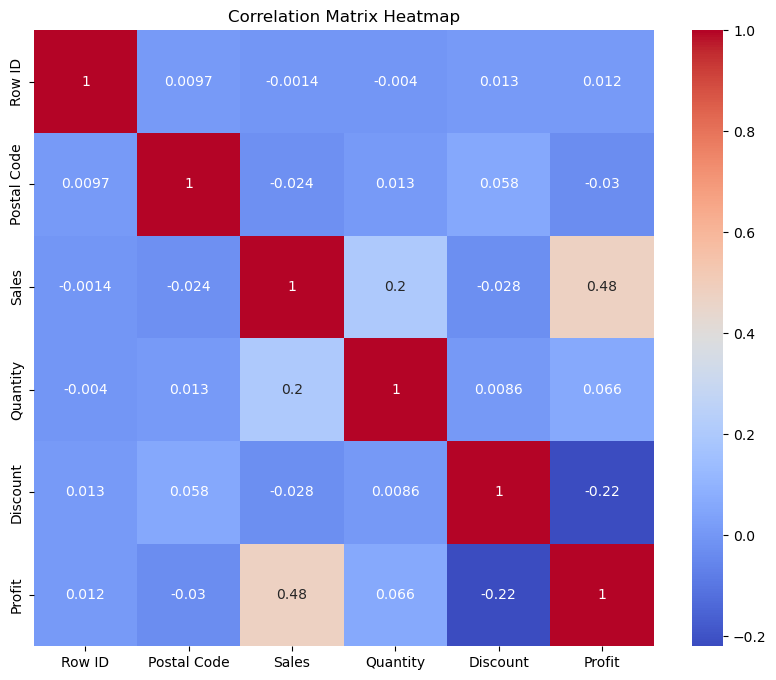

In [16]:
# Visualizing correlation matrix using heatmap
# Darker colors indicate stronger relationships

plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.show()


In [17]:
# Selecting only numerical columns for further analysis
# This is useful for boxplots, outlier detection, etc.

data_con = data.select_dtypes(include=[np.number])

data_con.head()


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
0,1,42420,261.9600,2,0.00,41.9136
1,2,42420,731.9400,3,0.00,219.5820
2,3,90036,14.6200,2,0.00,6.8714
3,4,33311,957.5775,5,0.45,-383.0310
4,5,33311,22.3680,2,0.20,2.5164


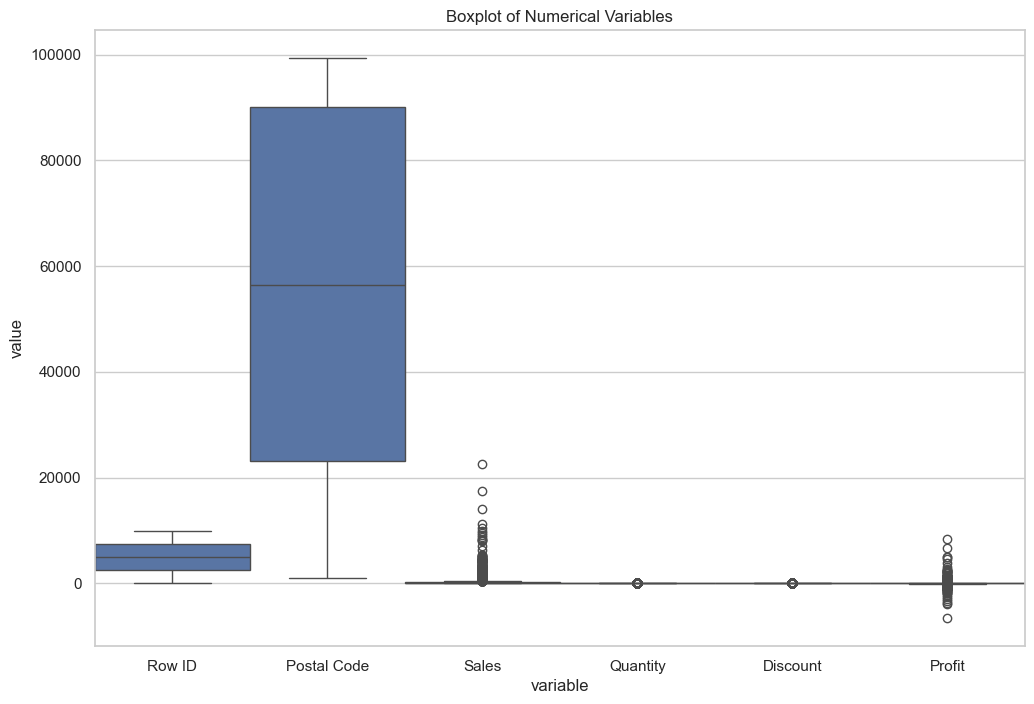

In [18]:
# Boxplot to visualize distribution and potential outliers
# Each box represents one numerical variable independently

plt.figure(figsize=[12,8])
sns.set(style="whitegrid")
sns.boxplot(
    x="variable",
    y="value",
    data=pd.melt(data_con),
    width=1
)
plt.title("Boxplot of Numerical Variables")
plt.show()


In [19]:
# Outlier Detection using Interquartile Range (IQR) method
# This is a statistical approach to identify outliers in numerical variables

numeric_data = data.select_dtypes(include='number')

Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1

outliers = (
    (numeric_data < (Q1 - 1.5 * IQR)) |
    (numeric_data > (Q3 + 1.5 * IQR))
)

# Counting number of outliers present in each numerical column
outlier_counts = outliers.sum()
outlier_counts


Row ID            0
Postal Code       0
Sales          1167
Quantity        170
Discount        856
Profit         1881
dtype: int64

In [20]:
# Z-Score based outlier detection function
# This function identifies rows where values deviate significantly
# from the mean using standard deviation

from scipy import stats

def remove_outliers_zscore(df, threshold=3):
    numeric_df = df.select_dtypes(include='number')
    z_scores = np.abs(stats.zscore(numeric_df))
    return df[(z_scores < threshold).all(axis=1)]


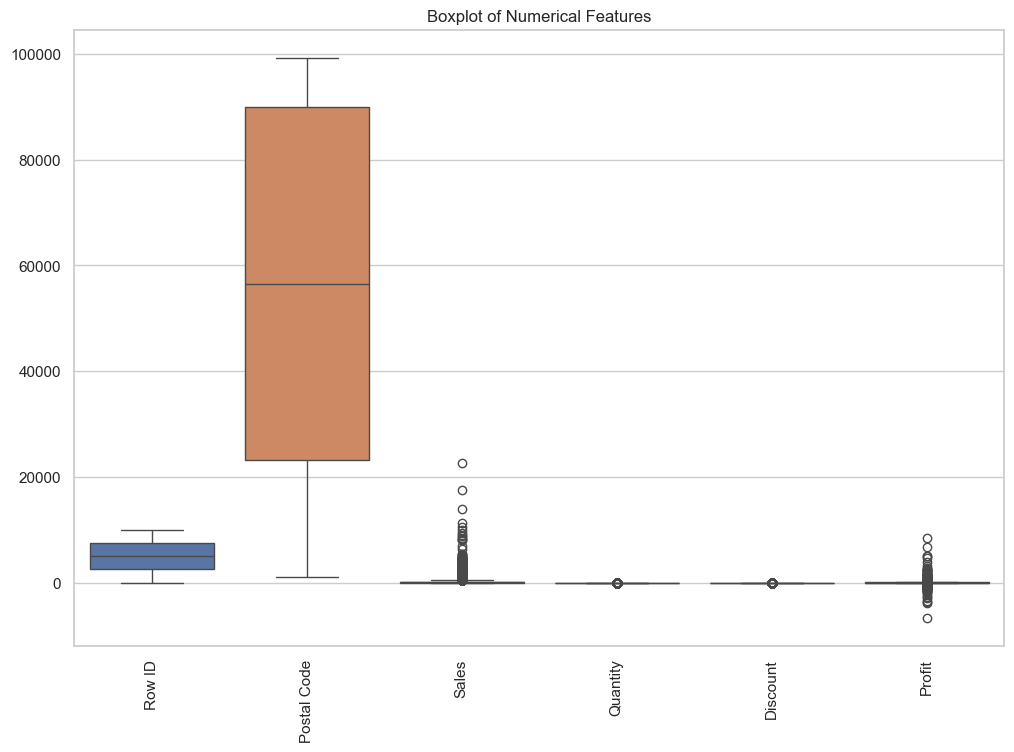

In [21]:
# Selecting only numerical columns from the dataset
# This is required because boxplots work on numerical data only

numeric_data = data.select_dtypes(include='number')

# Creating a boxplot for all numerical variables
# This helps visualize distribution, spread, and potential outliers
# Each box represents one numerical variable independently

plt.figure(figsize=(12,8))
sns.boxplot(data=numeric_data)
plt.xticks(rotation=90)  # Rotating labels for better readability
plt.title("Boxplot of Numerical Features")
plt.show()


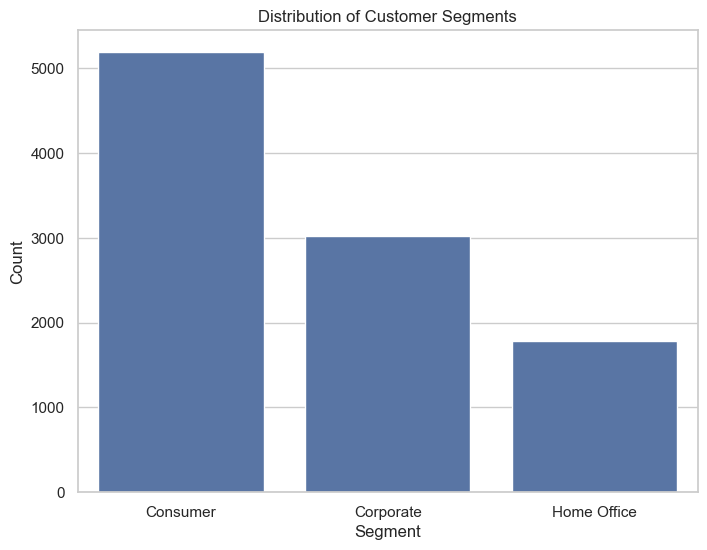

In [22]:
# Univariate Analysis: Frequency distribution of Customer Segment
# This count plot shows how frequently each customer segment appears

plt.figure(figsize=(8,6))
sns.countplot(x='Segment', data=data)
plt.title("Distribution of Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.show()


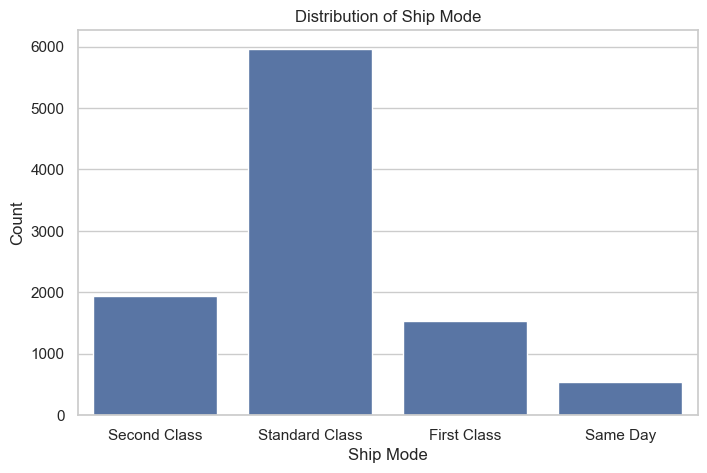

In [23]:
# Univariate Analysis: Frequency distribution of Ship Mode
# This count plot shows how often each shipping mode appears in the dataset

plt.figure(figsize=(8,5))
sns.countplot(x='Ship Mode', data=data)
plt.title("Distribution of Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Count")
plt.show()


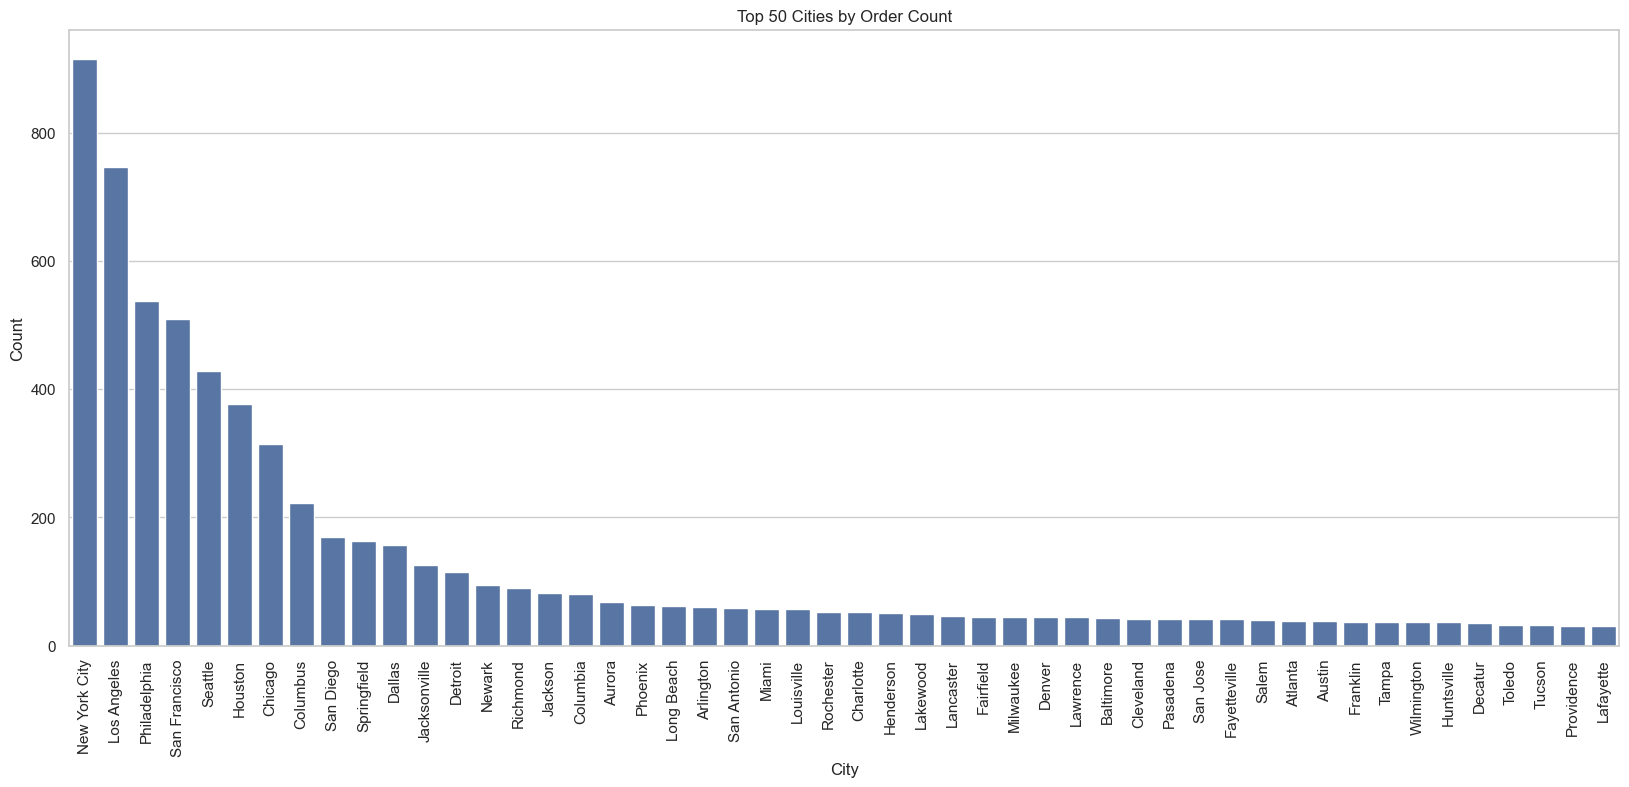

In [24]:
# Univariate Analysis: Frequency distribution of top 50 Cities
# This count plot shows which cities appear most frequently in the dataset

plt.figure(figsize=(20,8))
sns.countplot(
    x='City',
    data=data,
    order=data['City'].value_counts().head(50).index
)
plt.xticks(rotation=90)   # Rotate city names for readability
plt.title("Top 50 Cities by Order Count")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()


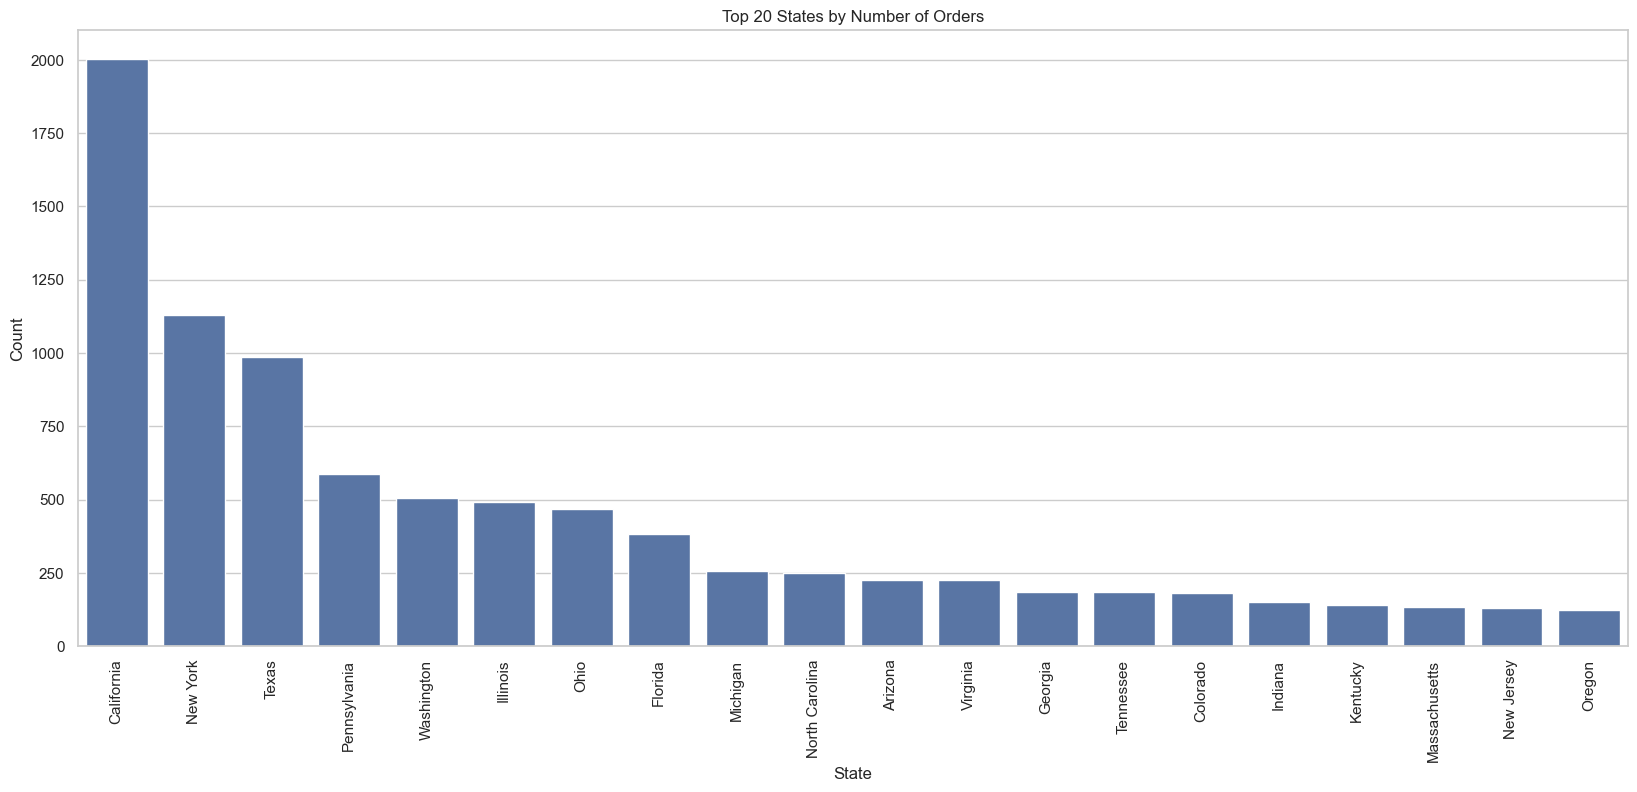

In [25]:
# Univariate Analysis: Frequency distribution of top 20 States
# This count plot shows which states have the highest number of orders

plt.figure(figsize=(20,8))
sns.countplot(
    x='State',
    data=data,
    order=data['State'].value_counts().head(20).index
)
plt.xticks(rotation=90)  # Rotate labels for readability
plt.title("Top 20 States by Number of Orders")
plt.xlabel("State")
plt.ylabel("Count")
plt.show()


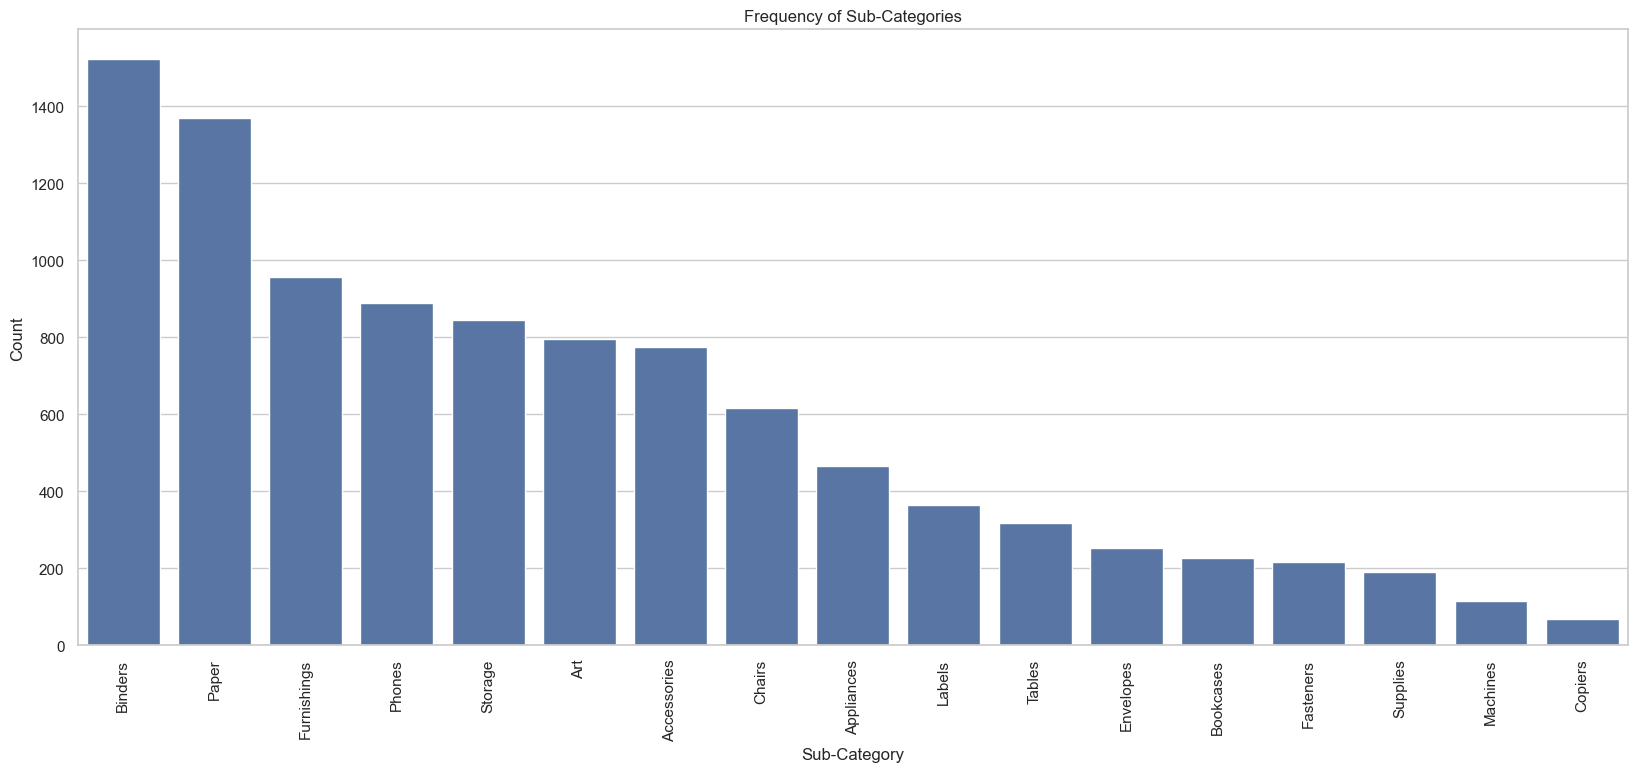

In [26]:
# Univariate Analysis: Frequency distribution of Sub-Categories
# This count plot shows how frequently each product sub-category appears in the dataset

plt.figure(figsize=(20,8))
sns.countplot(
    x='Sub-Category',
    data=data,
    order=data['Sub-Category'].value_counts().index
)
plt.xticks(rotation=90)  # Rotate labels for readability
plt.title("Frequency of Sub-Categories")
plt.xlabel("Sub-Category")
plt.ylabel("Count")
plt.show()


In [27]:
# Univariate Analysis (Advanced)
# Outlier Detection using Interquartile Range (IQR) Method
# This statistical method identifies outliers for each numerical variable

# Calculating first quartile (Q1) and third quartile (Q3)
Q1 = data_con.quantile(0.25)
Q3 = data_con.quantile(0.75)

# Computing Interquartile Range (IQR)
IQR = Q3 - Q1

# Identifying outliers:
# Values below (Q1 - 1.5*IQR) or above (Q3 + 1.5*IQR) are considered outliers
outliers = (
    (data_con < (Q1 - 1.5 * IQR)) |
    (data_con > (Q3 + 1.5 * IQR))
)

# Counting the number of outliers in each numerical column
outlier_counts = outliers.sum()
outlier_counts


Row ID            0
Postal Code       0
Sales          1167
Quantity        170
Discount        856
Profit         1881
dtype: int64

In [28]:
# Statistical Significance Testing using ANOVA

from scipy.stats import f_oneway

furniture_profit = data[data['Category'] == 'Furniture']['Profit']
office_profit = data[data['Category'] == 'Office Supplies']['Profit']
technology_profit = data[data['Category'] == 'Technology']['Profit']

f_stat, p_value = f_oneway(
    furniture_profit,
    office_profit,
    technology_profit
)

print("F-statistic:", f_stat)
print("P-value:", p_value)

# Hypothesis:
# H0: Mean profit is same across all categories
# H1: Mean profit differs for at least one category

# Conclusion:
# If p-value < 0.05, reject H0 → statistically significant difference exists


F-statistic: 54.31102304381536
P-value: 3.46991834622419e-24


In [29]:
#print(ds_con)
print(data_con.head())


   Row ID  Postal Code     Sales  Quantity  Discount    Profit
0       1        42420  261.9600         2      0.00   41.9136
1       2        42420  731.9400         3      0.00  219.5820
2       3        90036   14.6200         2      0.00    6.8714
3       4        33311  957.5775         5      0.45 -383.0310
4       5        33311   22.3680         2      0.20    2.5164


In [30]:
# Checking the shape of the dataset
# This shows the total number of rows and columns present in the data
# Format: (number_of_rows, number_of_columns)

data.shape


(9994, 21)

In [31]:
# Displaying the first 5 rows of the dataset
# This helps understand the structure, column names, and sample values

data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [32]:
# Displaying detailed information about the dataset
# Shows column names, data types, non-null counts, and memory usage

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [33]:
# Checking the number of unique values in each categorical (object-type) column
# This helps understand category diversity and is useful before frequency analysis

for col in data.columns:
    if data[col].dtype == 'object':
        print(f"Number of unique entries in {col} are {data[col].nunique()}")
        print("-" * 60)


Number of unique entries in Order ID are 5009
------------------------------------------------------------
Number of unique entries in Order Date are 1237
------------------------------------------------------------
Number of unique entries in Ship Date are 1334
------------------------------------------------------------
Number of unique entries in Ship Mode are 4
------------------------------------------------------------
Number of unique entries in Customer ID are 793
------------------------------------------------------------
Number of unique entries in Customer Name are 793
------------------------------------------------------------
Number of unique entries in Segment are 3
------------------------------------------------------------
Number of unique entries in Country are 1
------------------------------------------------------------
Number of unique entries in City are 531
------------------------------------------------------------
Number of unique entries in State are 49
--

## Bivariate & Multivariate Analysis


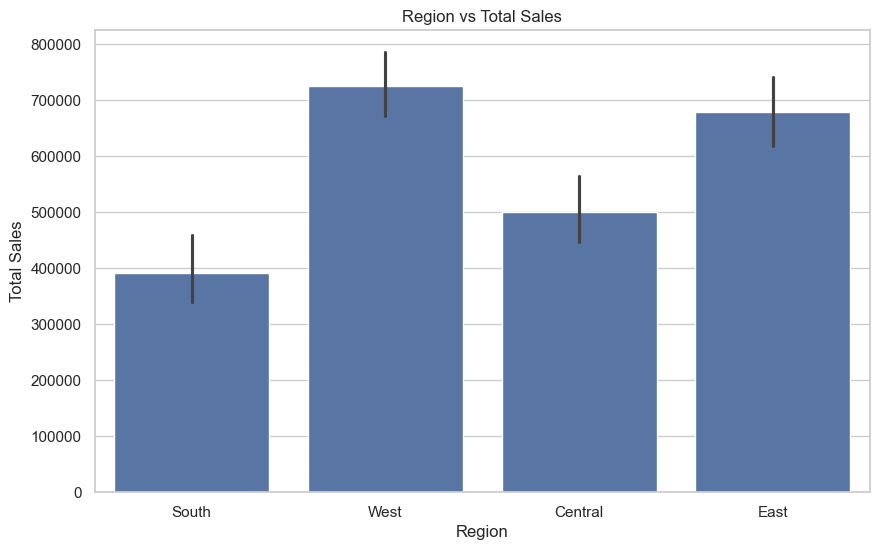

In [34]:
# Bivariate Analysis: Region vs Sales
# This bar plot shows how total sales vary across different regions
# Region is a categorical variable and Sales is a numerical variable

plt.figure(figsize=(10,6))
sns.barplot(
    x='Region',
    y='Sales',
    data=data,
    estimator=sum
)
plt.title("Region vs Total Sales")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()


In [35]:
# Checking for missing (null) values in each column
# This helps identify data quality issues before analysis

data.isnull().sum()


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [36]:
# Frequency analysis of the 'Sub-Category' column
# This shows how many times each sub-category appears in the dataset
# Useful for understanding category distribution before plotting

data['Sub-Category'].value_counts()


Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

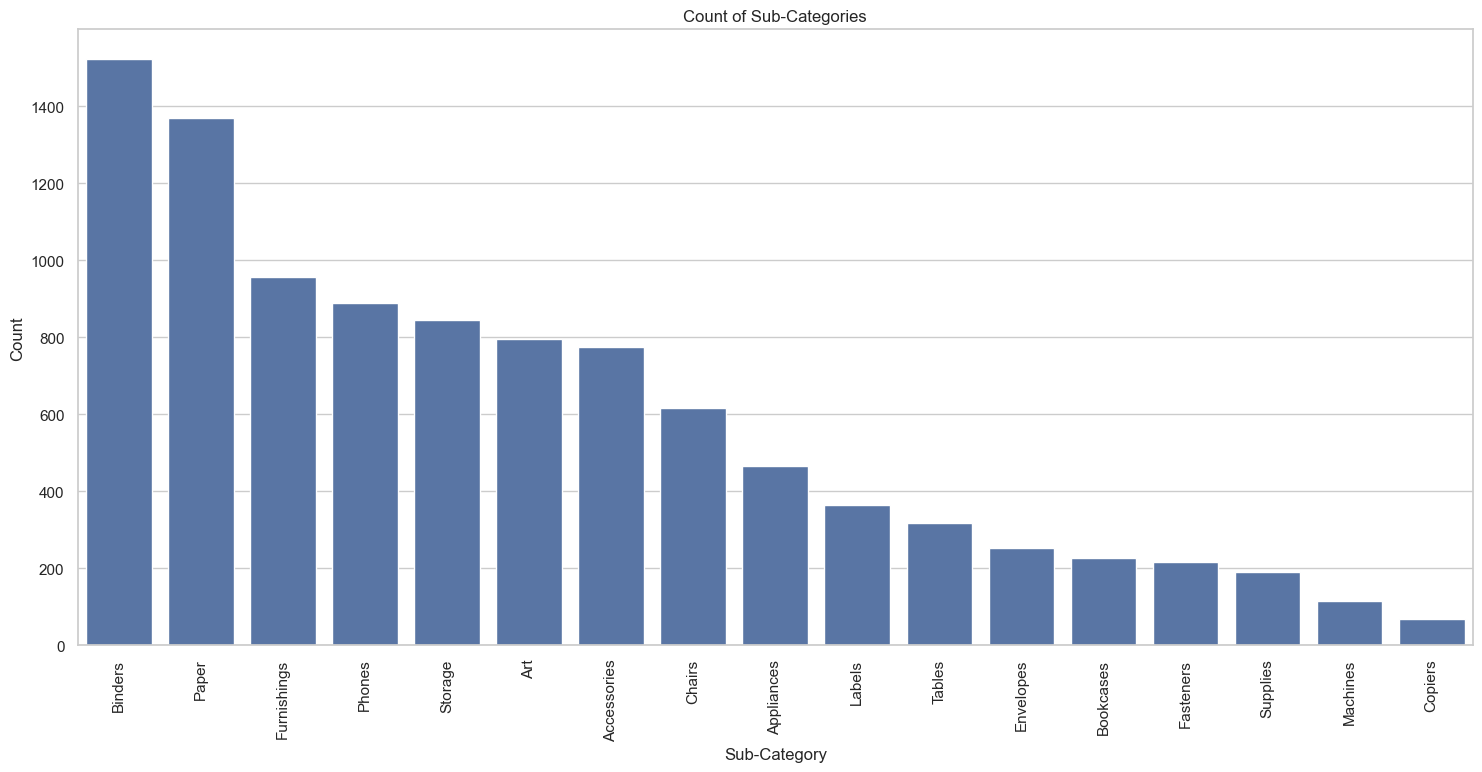

In [37]:
# Univariate Analysis: Frequency distribution of Sub-Category
# This count plot visualizes how frequently each sub-category appears
# It helps identify the most and least common product sub-categories

plt.figure(figsize=(18,8))
sns.countplot(
    x='Sub-Category',
    data=data,
    order=data['Sub-Category'].value_counts().index
)
plt.xticks(rotation=90)          # Rotate labels for readability
plt.title("Count of Sub-Categories")
plt.xlabel("Sub-Category")
plt.ylabel("Count")
plt.show()


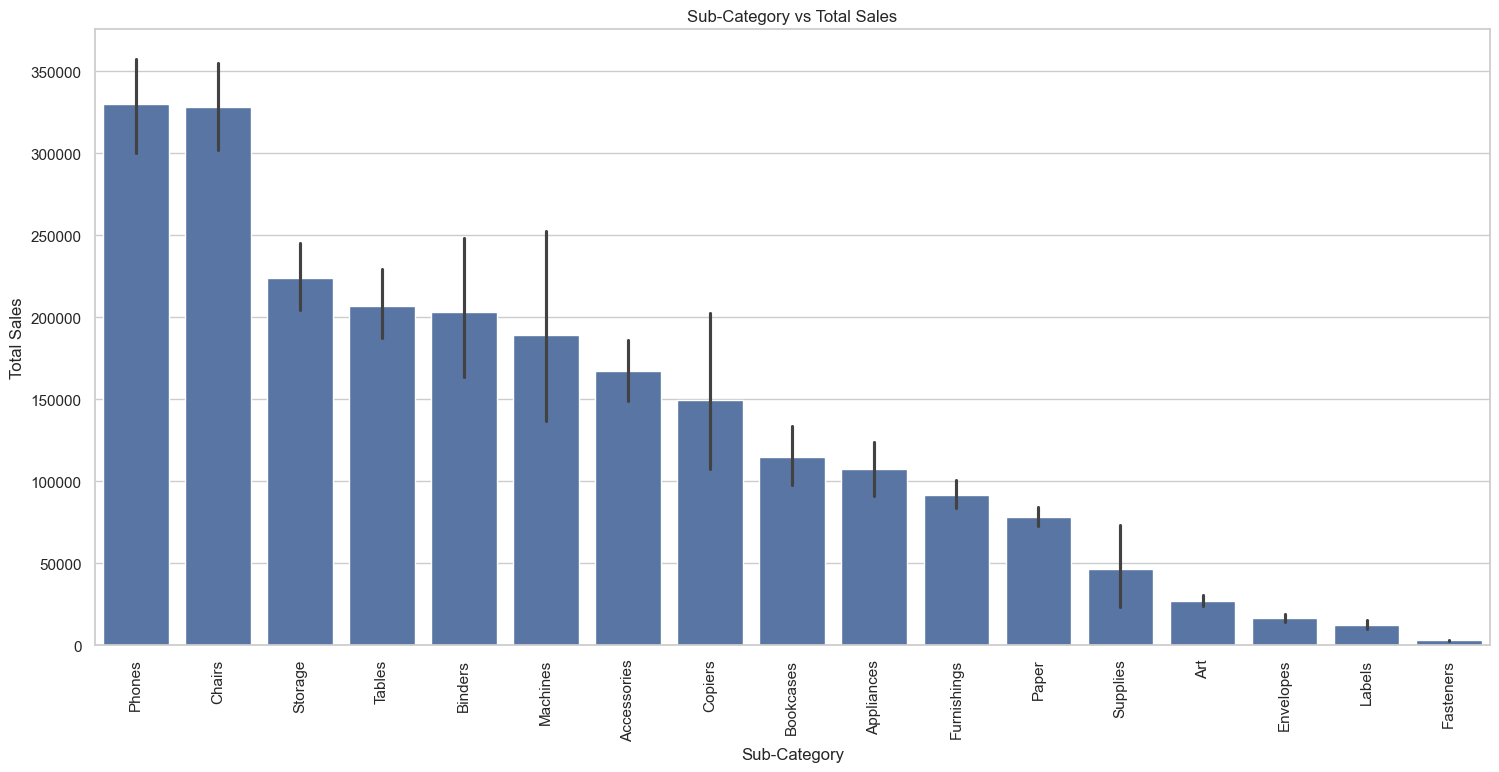

In [38]:
# Bivariate Analysis: Sub-Category vs Total Sales
# This bar plot shows how total sales vary across product sub-categories
# Sub-Category is categorical, Sales is numerical

plt.figure(figsize=(18,8))
sns.barplot(
    x='Sub-Category',
    y='Sales',
    data=data,
    estimator=sum,
    order=data.groupby('Sub-Category')['Sales']
         .sum()
         .sort_values(ascending=False)
         .index
)
plt.xticks(rotation=90)  # Rotate labels for readability
plt.title("Sub-Category vs Total Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.show()


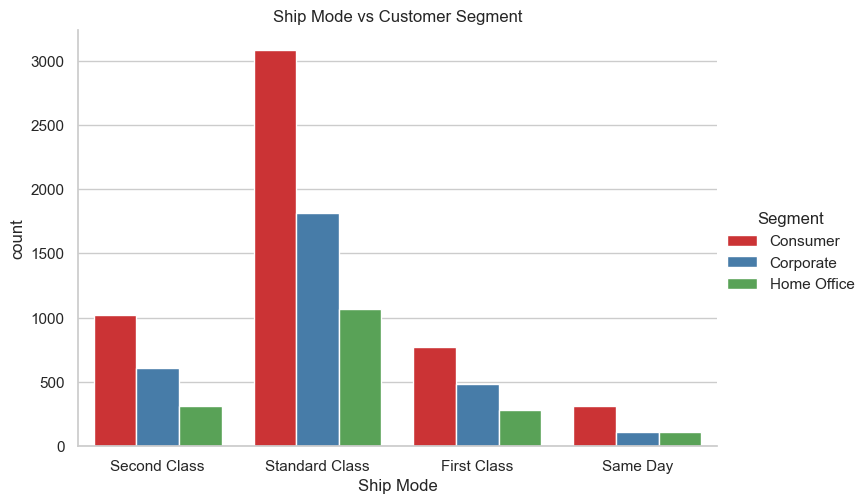

In [39]:
# Bivariate Analysis: Ship Mode vs Customer Segment
# This count plot shows how customer segments are distributed
# across different shipping modes

sns.catplot(
    x="Ship Mode",
    hue="Segment",
    data=data,
    kind="count",
    aspect=1.5,
    palette="Set1"
)

plt.title("Ship Mode vs Customer Segment")
plt.show()


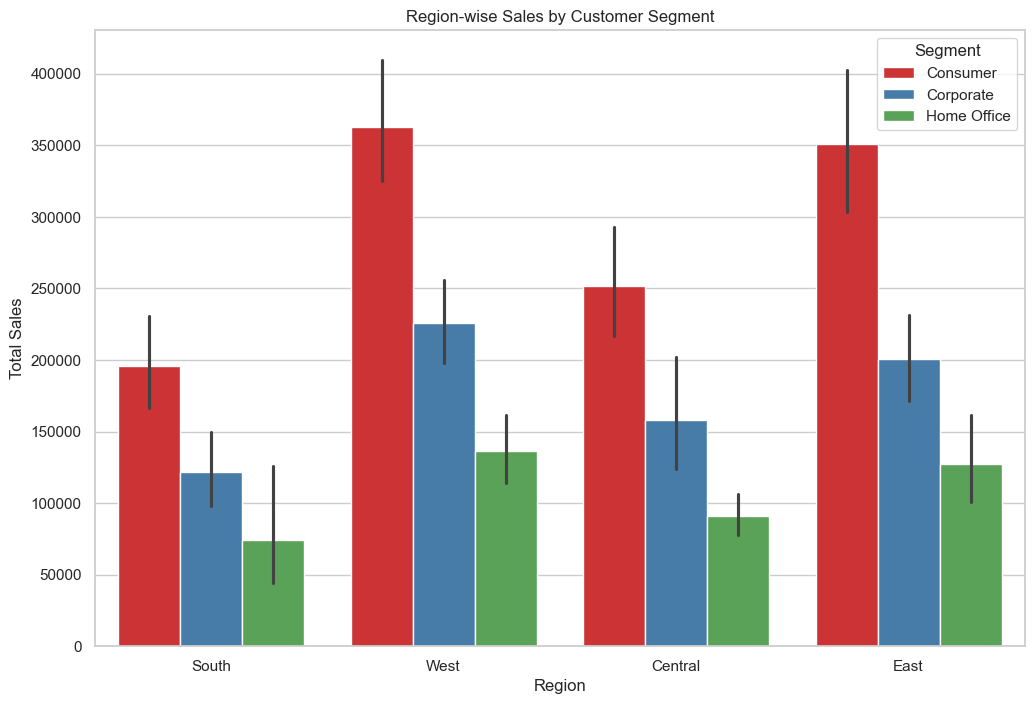

In [40]:
# Multivariate Analysis: Interaction between Region and Segment on Sales
# This bar plot shows how total sales vary across regions
# while comparing different customer segments within each region

plt.figure(figsize=(12,8))
ax = sns.barplot(
    x="Region",
    y="Sales",
    hue="Segment",
    data=data,
    estimator=sum,
    palette="Set1"
)

plt.title("Region-wise Sales by Customer Segment")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()


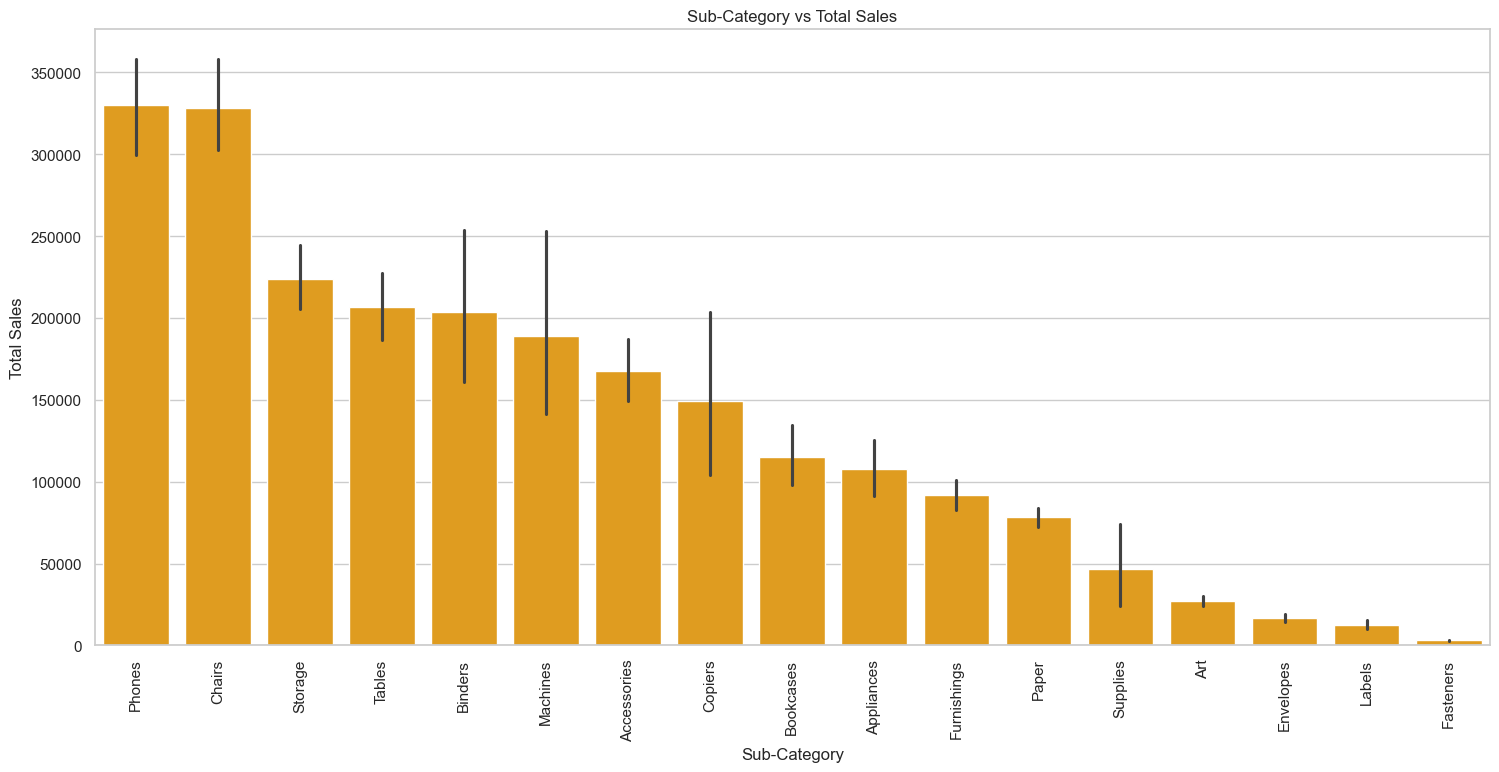

In [41]:
# Bivariate Analysis: Sub-Category vs Total Sales
# This bar plot shows how total sales are distributed across product sub-categories
# Sub-Category is categorical and Sales is numerical

plt.figure(figsize=(18,8))
sns.barplot(
    x="Sub-Category",
    y="Sales",
    data=data,
    estimator=sum,
    order=data.groupby("Sub-Category")["Sales"]
         .sum()
         .sort_values(ascending=False)
         .index,
    color="orange"
)
plt.xticks(rotation=90)  # Rotate labels for readability
plt.title("Sub-Category vs Total Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.show()


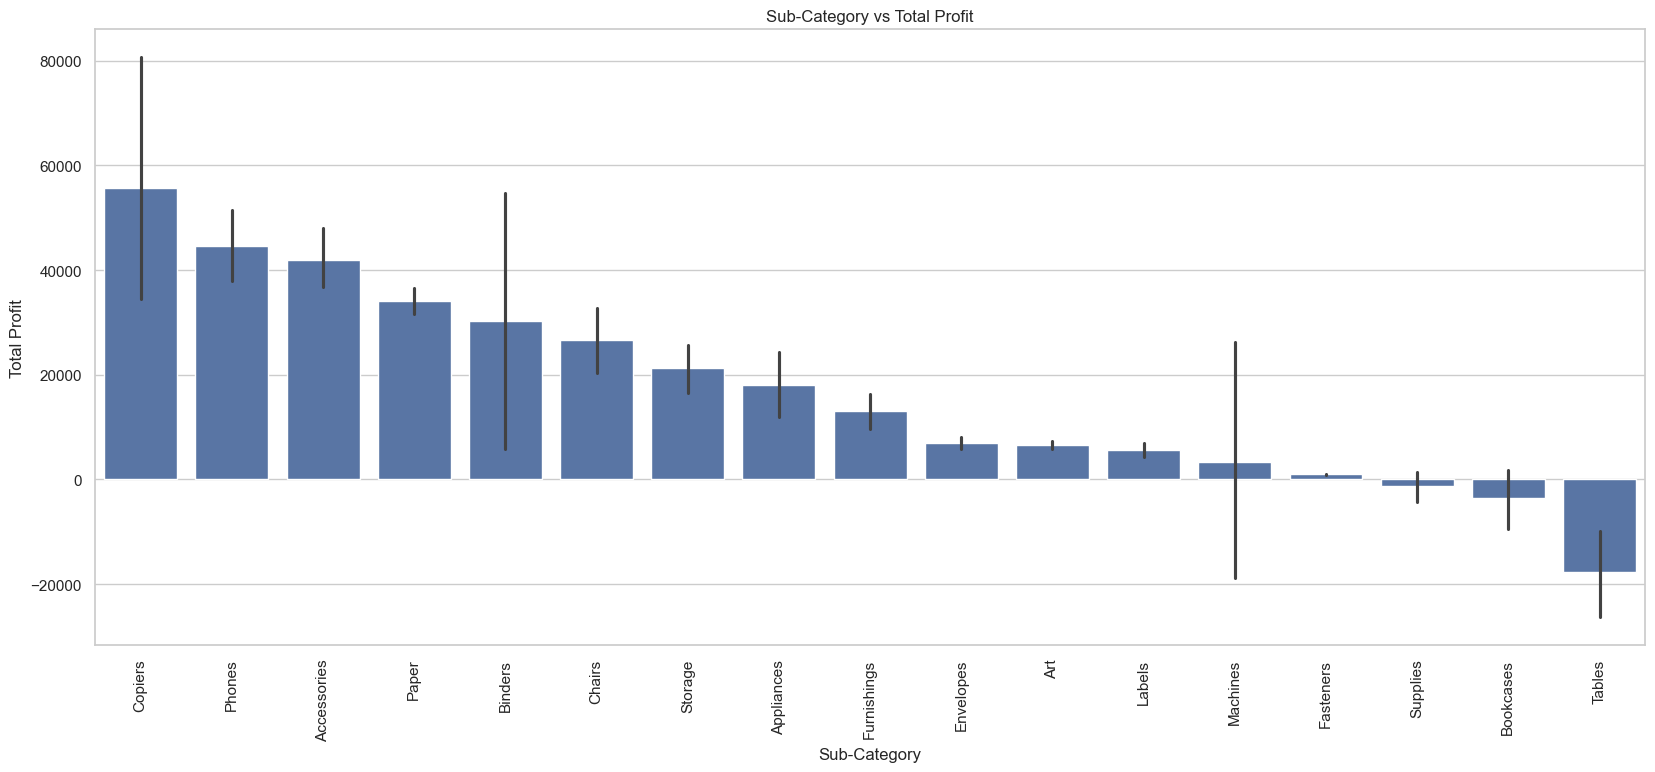

In [42]:
# Bivariate Analysis: Sub-Category vs Total Profit
# This bar plot shows how total profit varies across product sub-categories
# Sub-Category is categorical and Profit is numerical

plt.figure(figsize=(20,8))
sns.barplot(
    x='Sub-Category',
    y='Profit',
    data=data,
    estimator=sum,
    order=data.groupby('Sub-Category')['Profit']
         .sum()
         .sort_values(ascending=False)
         .index
)
plt.xticks(rotation=90)  # Rotate labels for readability
plt.title("Sub-Category vs Total Profit")
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")
plt.show()


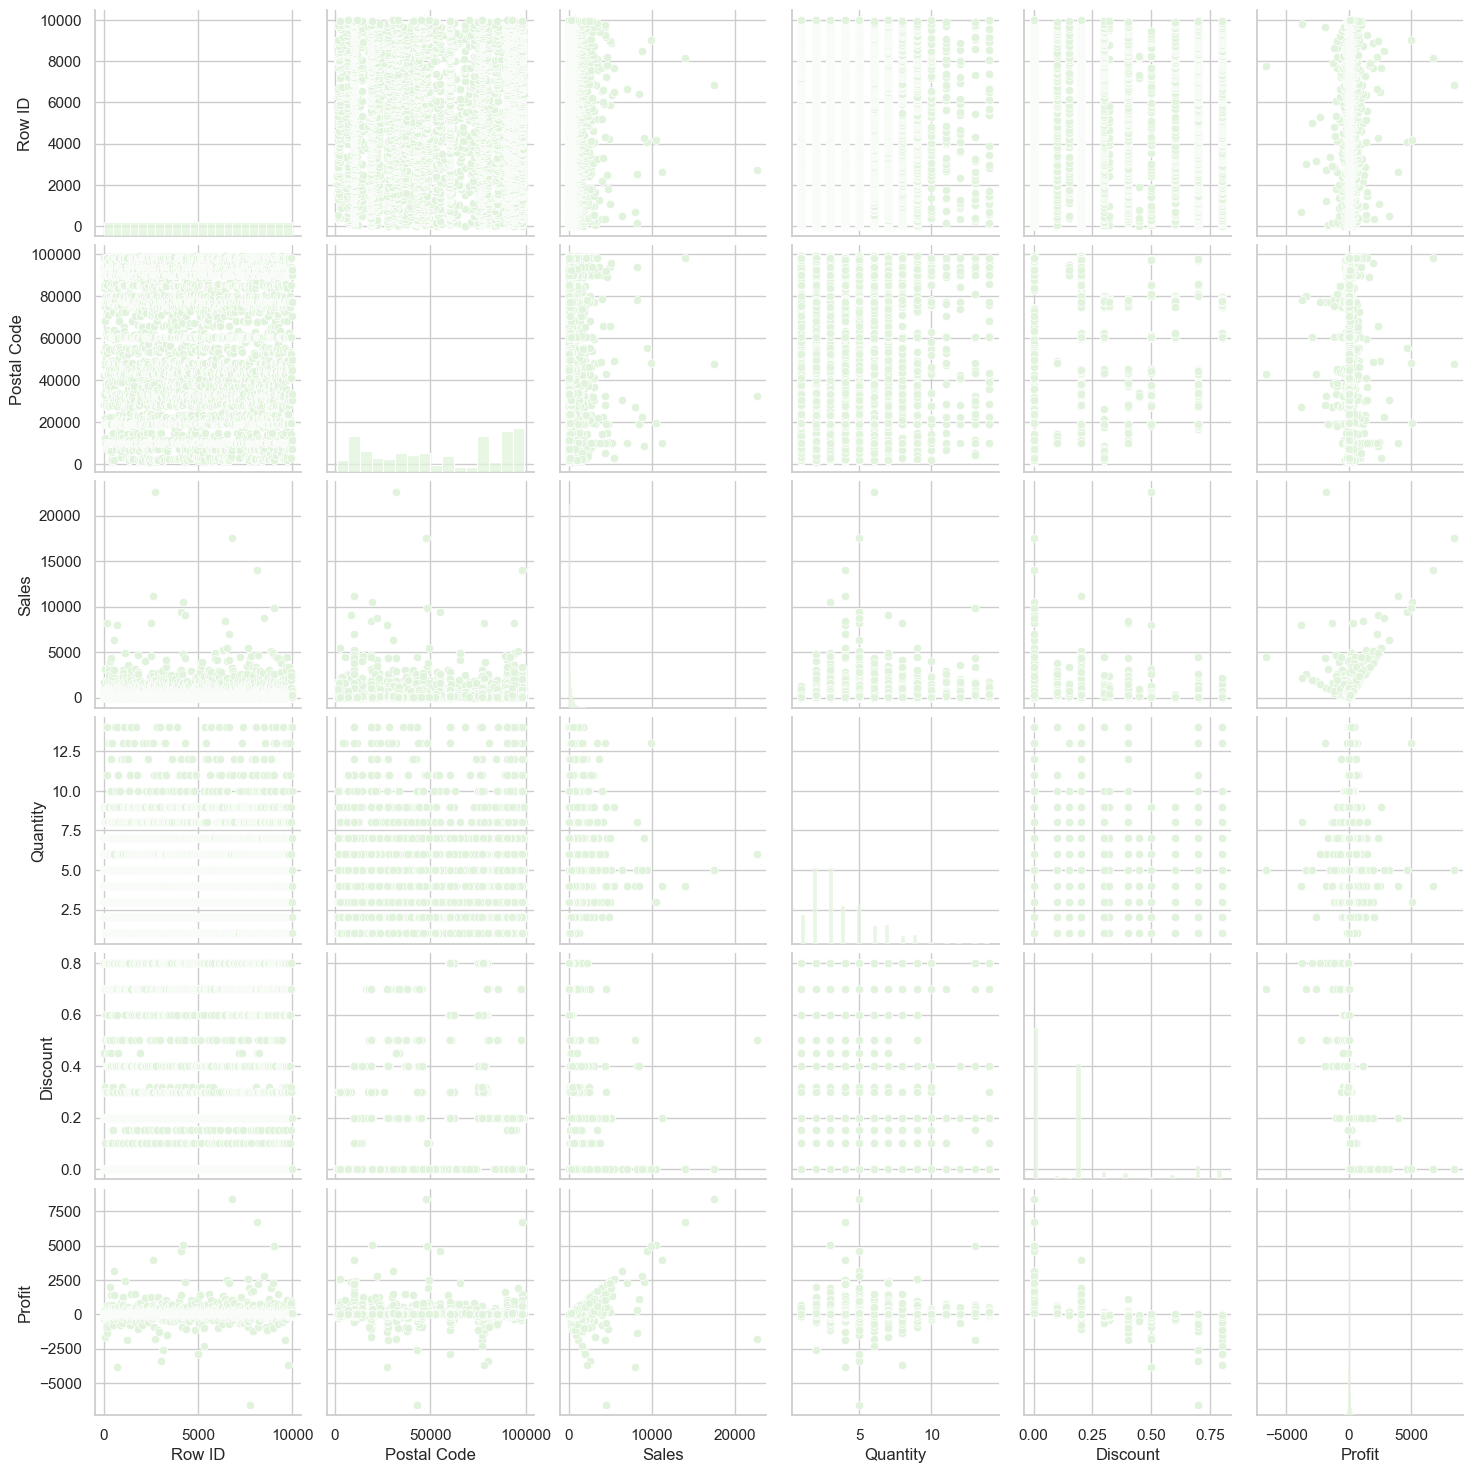

In [43]:
# Multivariate Analysis: Scatter Plot Matrix (Pair Plot)
# This pair plot visualizes relationships between multiple numerical variables
# Diagonal plots show distributions, off-diagonal plots show pairwise relationships

sns.set_palette('Greens')
sns.pairplot(data_con)
plt.show()


C:\Users\valla\AppData\Local\Temp\ipykernel_36492\2733543561.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


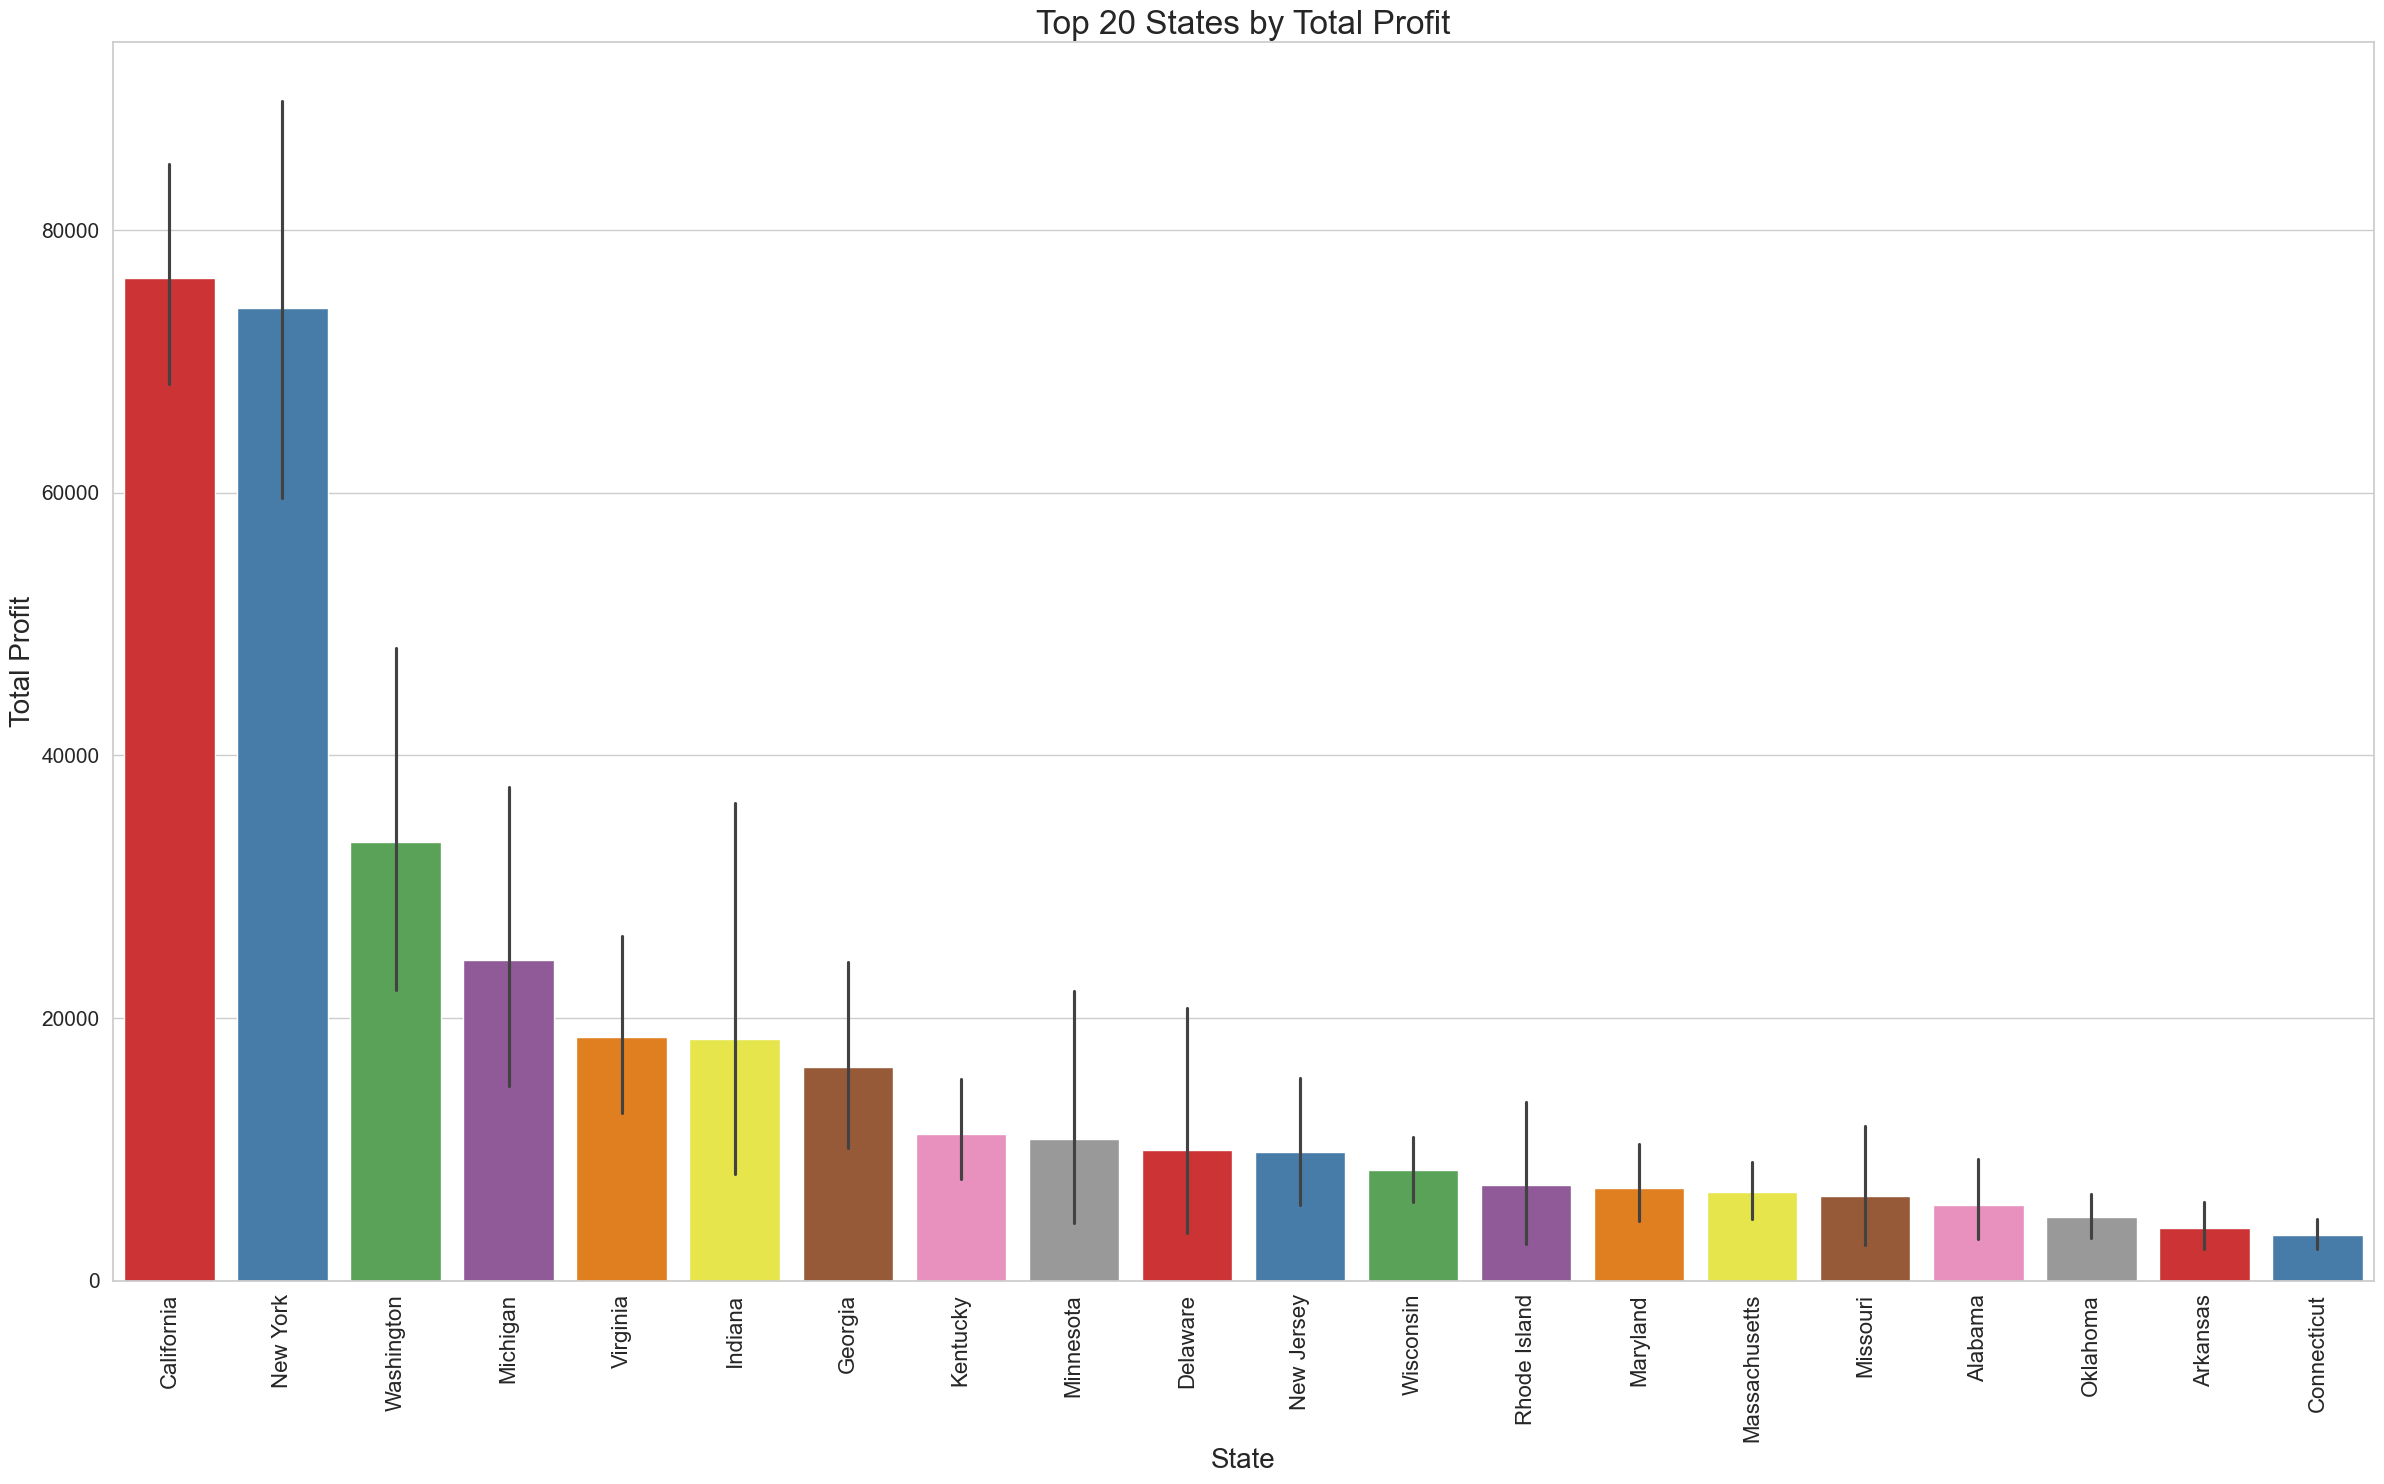

In [44]:
# Bivariate Analysis: State vs Total Profit
# This bar plot shows how total profit varies across states
# Only the top 20 states by total profit are displayed

plt.figure(figsize=(24,15))
sns.barplot(
    x="State",
    y="Profit",
    data=data,
    estimator=sum,
    order=data.groupby("State")["Profit"]
         .sum()
         .sort_values(ascending=False)
         .head(20)
         .index,
    palette="Set1"
)

plt.xticks(rotation=90, fontsize=16)
plt.yticks(fontsize=15)
plt.title("Top 20 States by Total Profit", fontsize=24)
plt.xlabel("State", fontsize=20)
plt.ylabel("Total Profit", fontsize=20)
plt.tight_layout()
plt.show()


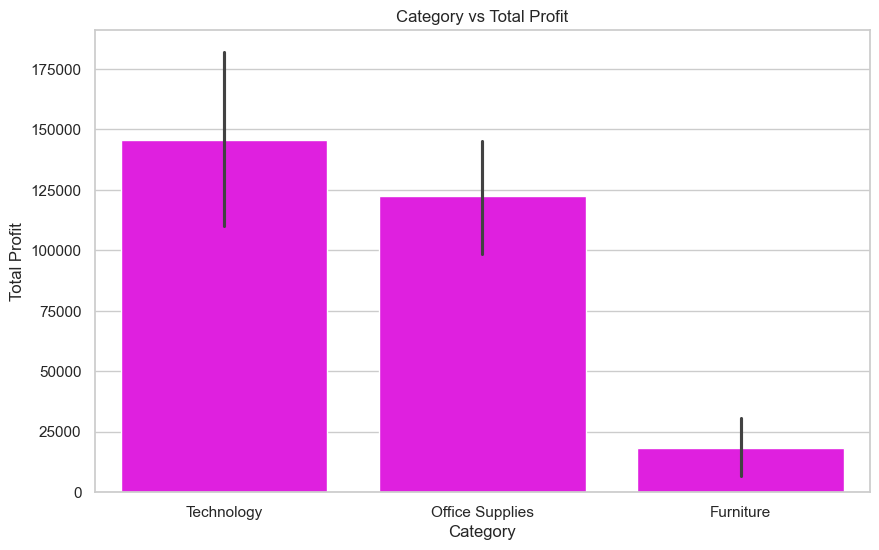

In [45]:
# Bivariate Analysis: Category vs Total Profit
# This bar plot shows how total profit varies across product categories
# Category is categorical and Profit is numerical

plt.figure(figsize=(10,6))
sns.barplot(
    x="Category",
    y="Profit",
    data=data,
    estimator=sum,
    order=data.groupby("Category")["Profit"]
         .sum()
         .sort_values(ascending=False)
         .index,
    color="magenta"
)
plt.title("Category vs Total Profit")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()


C:\Users\valla\AppData\Local\Temp\ipykernel_36492\3089942079.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


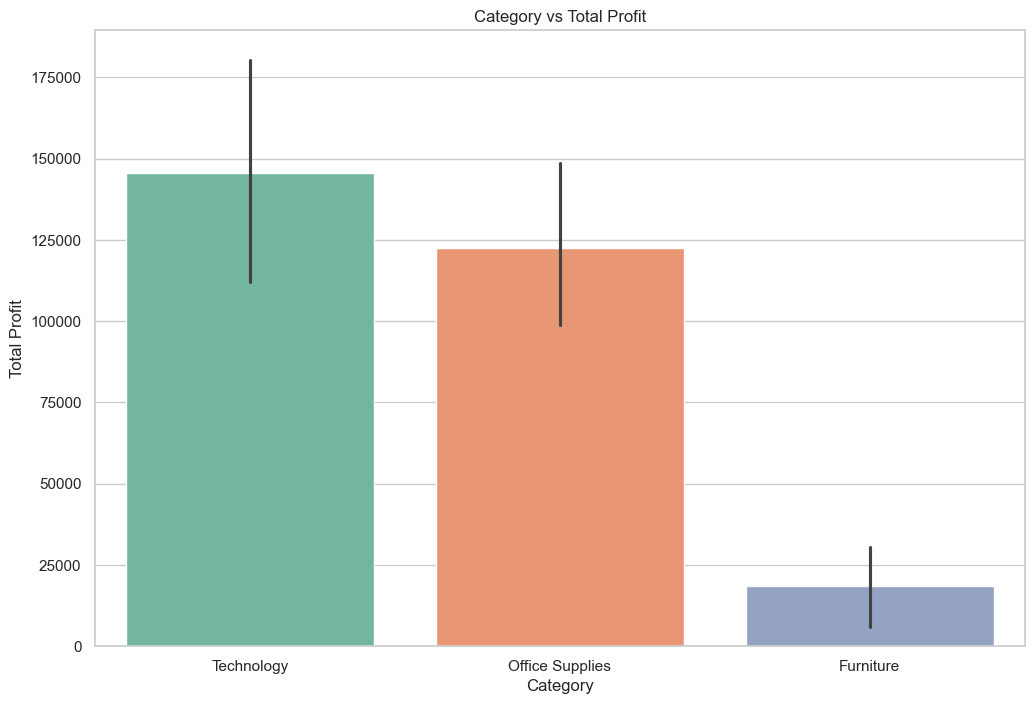

In [46]:
# Bivariate Analysis: Category vs Total Profit
# This bar plot shows how total profit varies across product categories
# Category is categorical and Profit is numerical

plt.figure(figsize=(12,8))
ax = sns.barplot(
    x="Category",
    y="Profit",
    data=data,
    estimator=sum,
    order=data.groupby("Category")["Profit"]
         .sum()
         .sort_values(ascending=False)
         .index,
    palette="Set2"
)

plt.title("Category vs Total Profit")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()


C:\Users\valla\AppData\Local\Temp\ipykernel_36492\3329136503.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


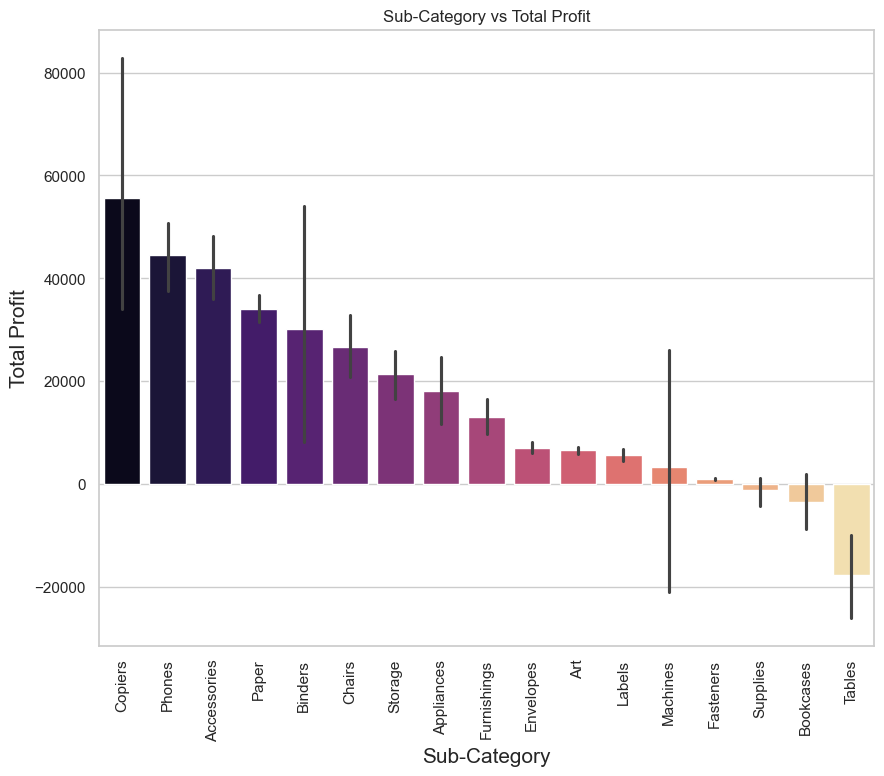

In [47]:
# Bivariate Analysis: Sub-Category vs Total Profit
# This bar plot shows how total profit varies across product sub-categories
# Sub-Category is categorical and Profit is numerical

plt.figure(figsize=(10,8))
sns.barplot(
    x="Sub-Category",
    y="Profit",
    data=data,
    estimator=sum,
    order=data.groupby("Sub-Category")["Profit"]
         .sum()
         .sort_values(ascending=False)
         .index,
    palette="magma"
)

plt.xlabel("Sub-Category", fontsize=15)
plt.ylabel("Total Profit", fontsize=15)
plt.xticks(rotation=90)  # Rotate labels for readability
plt.title("Sub-Category vs Total Profit")
plt.show()


In [48]:
# Creating a subset of data for Technology category
# This filtered dataset will be used for category-specific analysis

data_tech = data[data['Category'] == "Technology"]


C:\Users\valla\AppData\Local\Temp\ipykernel_36492\986687748.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


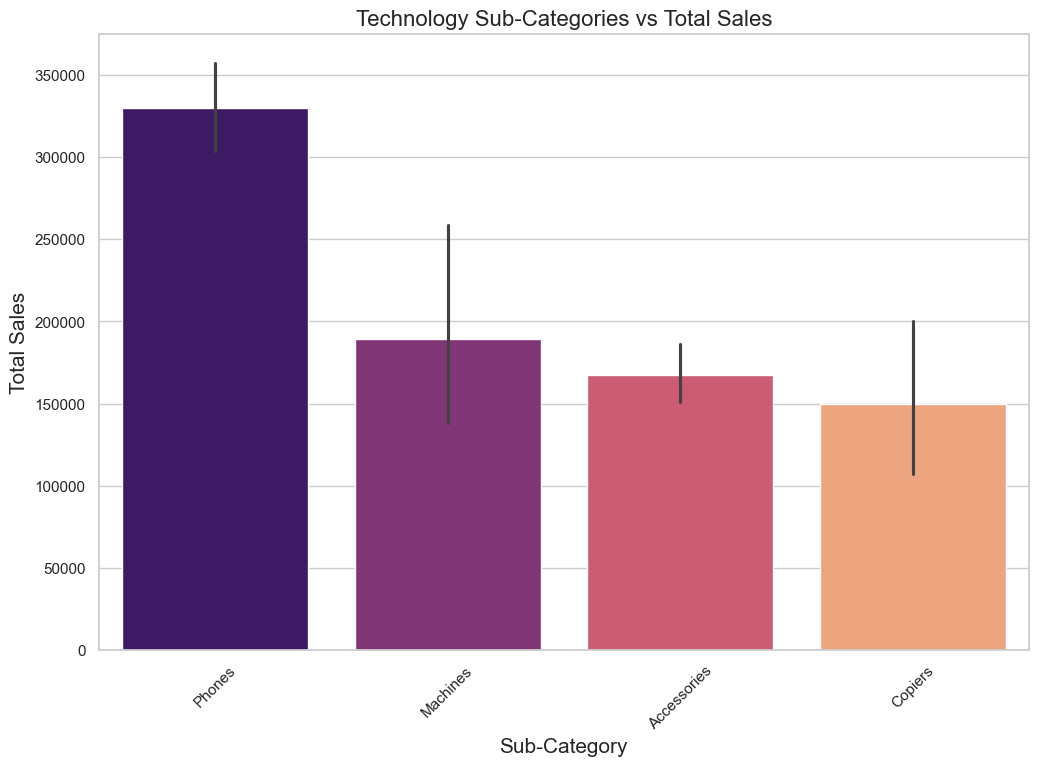

In [49]:
# Bivariate Analysis: Technology Sub-Category vs Total Sales
# This bar plot shows how total sales are distributed across
# Technology product sub-categories

plt.figure(figsize=(12,8))
sns.barplot(
    x="Sub-Category",
    y="Sales",
    data=data_tech,
    estimator=sum,
    order=data_tech.groupby("Sub-Category")["Sales"]
         .sum()
         .sort_values(ascending=False)
         .index,
    palette="magma"
)

plt.xlabel("Sub-Category", fontsize=15)
plt.ylabel("Total Sales", fontsize=15)
plt.title("Technology Sub-Categories vs Total Sales", fontsize=16)
plt.xticks(rotation=45)
plt.show()


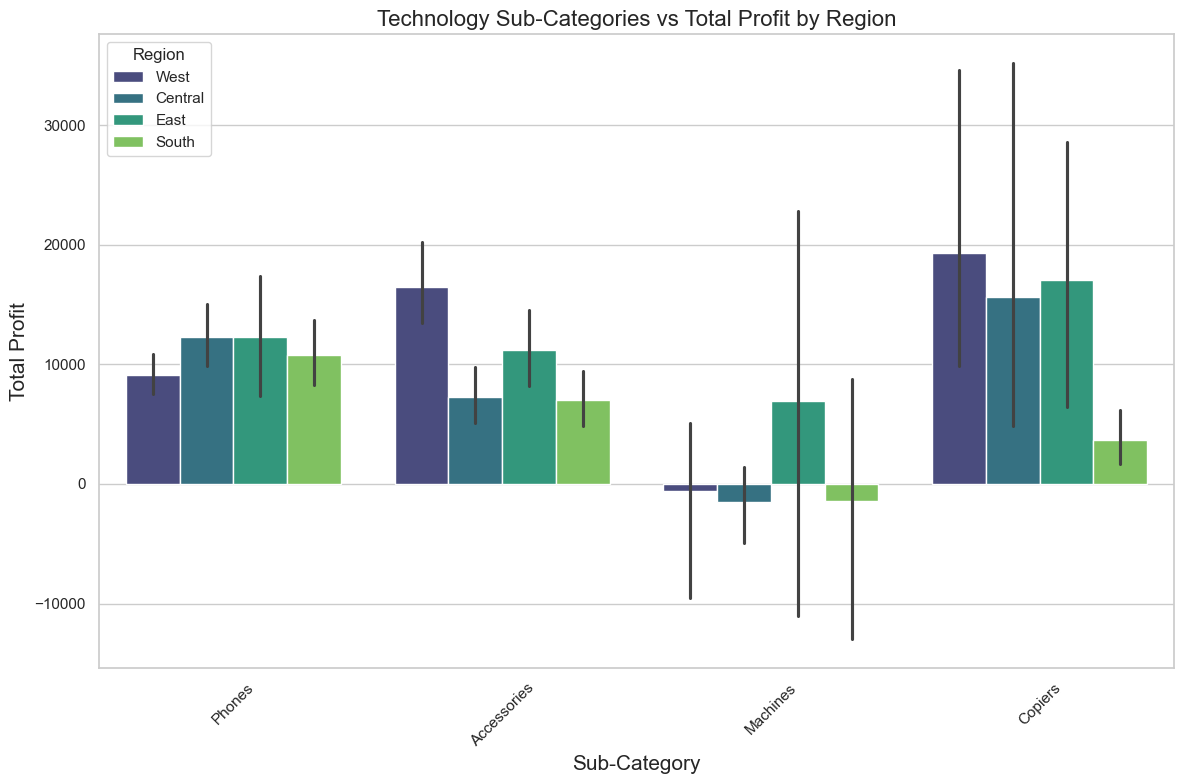

In [50]:
# Multivariate Analysis: Interaction between Sub-Category and Region on Profit (Technology)
# This bar plot shows how total profit varies across Technology sub-categories
# while comparing different regions within each sub-category

# Filter Technology category
data_tech = data[data['Category'] == "Technology"]

plt.figure(figsize=(12,8))
sns.barplot(
    x="Sub-Category",
    y="Profit",
    hue="Region",
    data=data_tech,
    estimator=sum,
    palette="viridis"
)

plt.xlabel("Sub-Category", fontsize=15)
plt.ylabel("Total Profit", fontsize=15)
plt.title("Technology Sub-Categories vs Total Profit by Region", fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


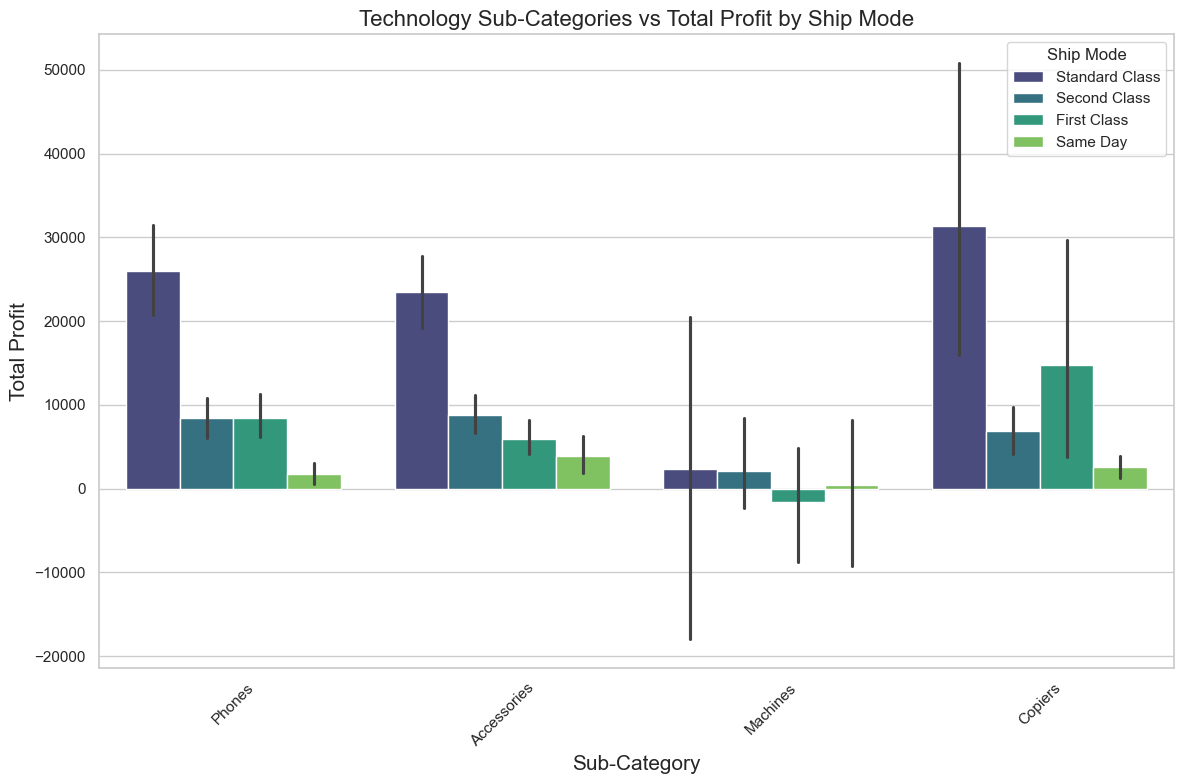

In [51]:
# Multivariate Analysis: Interaction between Sub-Category and Ship Mode on Profit (Technology)
# This bar plot shows how total profit varies across Technology sub-categories
# while comparing different shipping modes within each sub-category

# Filter Technology category
data_tech = data[data['Category'] == "Technology"]

plt.figure(figsize=(12,8))
sns.barplot(
    x="Sub-Category",
    y="Profit",
    hue="Ship Mode",
    data=data_tech,
    estimator=sum,
    palette="viridis"
)

plt.xlabel("Sub-Category", fontsize=15)
plt.ylabel("Total Profit", fontsize=15)
plt.title("Technology Sub-Categories vs Total Profit by Ship Mode", fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Time Series Analysis


In [54]:
# Converting Order Date column to datetime format
# This is mandatory for time series analysis

data['Order Date'] = pd.to_datetime(data['Order Date'])


In [55]:
# Sorting data by Order Date to maintain chronological order

data = data.sort_values('Order Date')


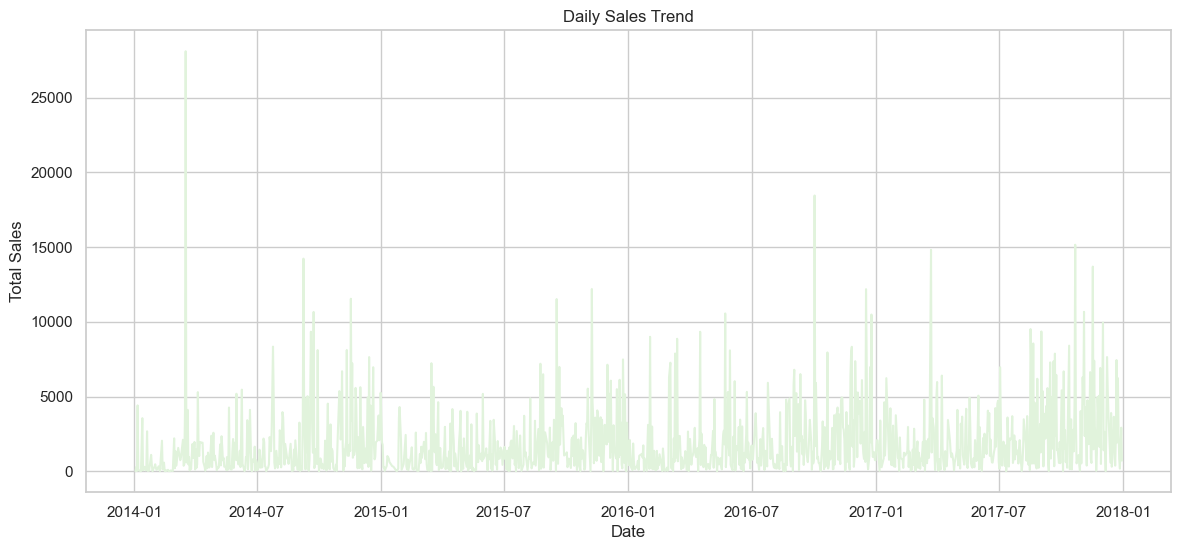

In [56]:
# Time Series Analysis: Daily Sales Trend
# Shows how total sales change day by day

daily_sales = data.groupby('Order Date')['Sales'].sum()

plt.figure(figsize=(14,6))
plt.plot(daily_sales.index, daily_sales.values)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()


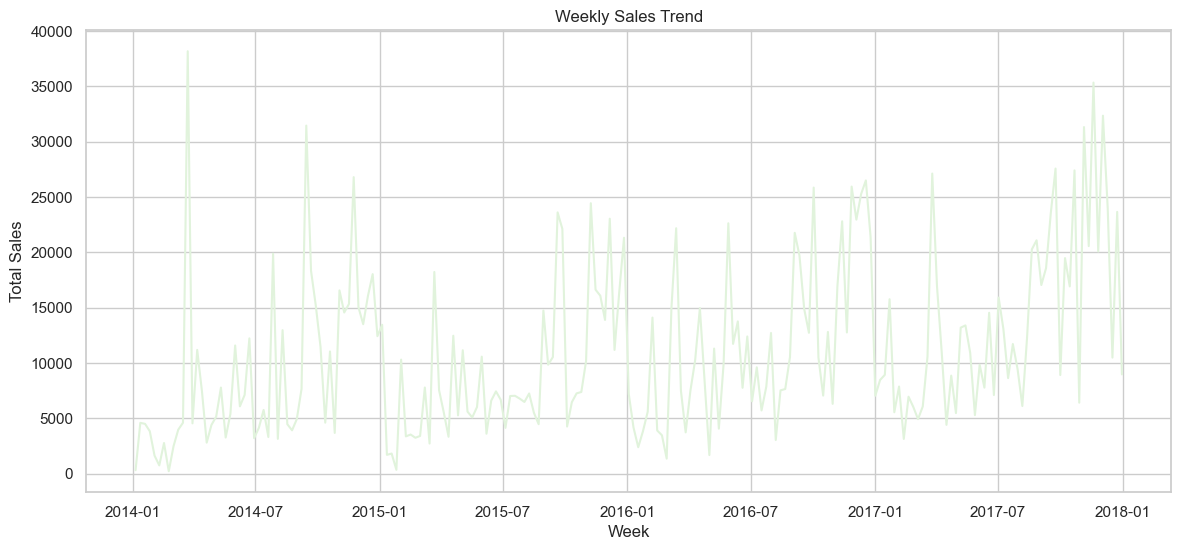

In [57]:
# Weekly Sales Trend
# Aggregating sales on a weekly basis to smooth daily fluctuations

weekly_sales = data.resample('W', on='Order Date')['Sales'].sum()

plt.figure(figsize=(14,6))
plt.plot(weekly_sales.index, weekly_sales.values)
plt.title("Weekly Sales Trend")
plt.xlabel("Week")
plt.ylabel("Total Sales")
plt.show()


C:\Users\valla\AppData\Local\Temp\ipykernel_36492\82182595.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = data.resample('M', on='Order Date')['Sales'].sum()


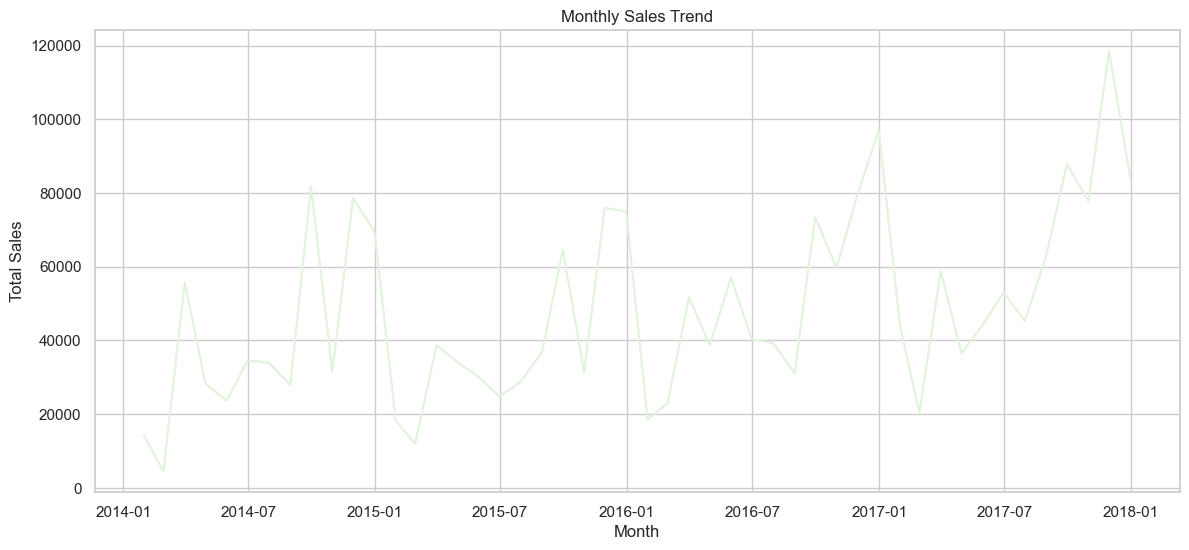

In [58]:
# Monthly Sales Trend
# Helps observe long-term growth or decline patterns

monthly_sales = data.resample('M', on='Order Date')['Sales'].sum()

plt.figure(figsize=(14,6))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()


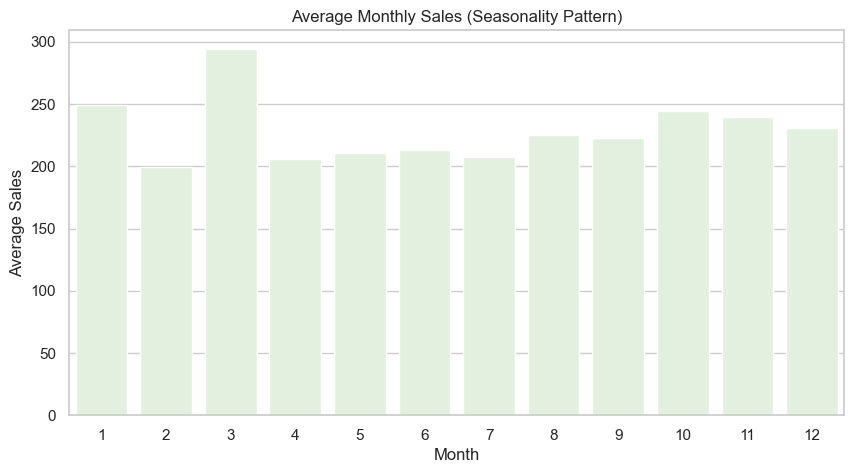

In [59]:
# Seasonality Analysis
# Checking if certain months consistently show higher or lower sales

data['Month'] = data['Order Date'].dt.month
monthly_seasonality = data.groupby('Month')['Sales'].mean()

plt.figure(figsize=(10,5))
sns.barplot(x=monthly_seasonality.index, y=monthly_seasonality.values)
plt.title("Average Monthly Sales (Seasonality Pattern)")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()


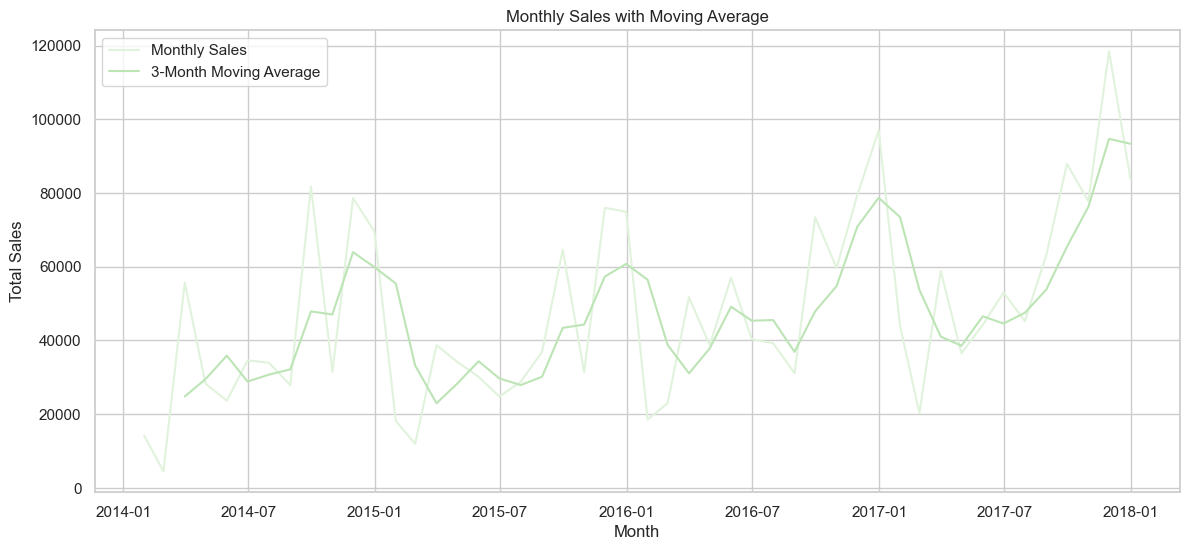

In [60]:
# Moving Average Calculation
# Smooths short-term fluctuations to highlight overall trend

monthly_sales_ma = monthly_sales.rolling(window=3).mean()

plt.figure(figsize=(14,6))
plt.plot(monthly_sales.index, monthly_sales.values, label='Monthly Sales')
plt.plot(monthly_sales_ma.index, monthly_sales_ma.values, label='3-Month Moving Average')
plt.title("Monthly Sales with Moving Average")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend()
plt.show()


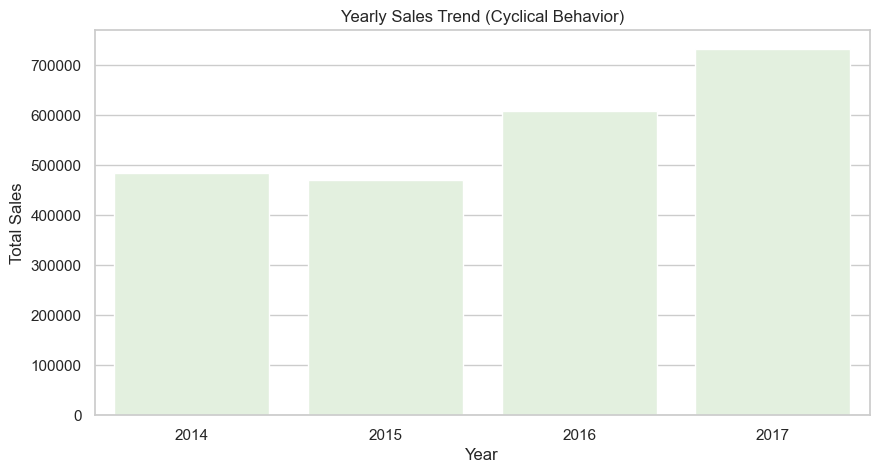

In [61]:
# Cyclical Behavior Analysis
# Observing sales variation across years

data['Year'] = data['Order Date'].dt.year
yearly_sales = data.groupby('Year')['Sales'].sum()

plt.figure(figsize=(10,5))
sns.barplot(x=yearly_sales.index, y=yearly_sales.values)
plt.title("Yearly Sales Trend (Cyclical Behavior)")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()


## Customer & Product Analysis


In [62]:
# Customer Segmentation Analysis
# Aggregating customer-level metrics for segmentation

customer_summary = data.groupby('Customer ID').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).reset_index()

customer_summary.rename(columns={
    'Sales': 'Total_Sales',
    'Profit': 'Total_Profit',
    'Order ID': 'Order_Count'
}, inplace=True)

customer_summary.head()


,Customer ID,Total_Sales,Total_Profit,Order_Count
0,AA-10315,5563.560,-362.8825,5
1,AA-10375,1056.390,277.3824,9
2,AA-10480,1790.512,435.8274,4
3,AA-10645,5086.935,857.8033,6
4,AB-10015,886.156,129.3465,3


In [63]:
# Segmenting customers based on total sales (Low / Medium / High)

customer_summary['Sales_Segment'] = pd.qcut(
    customer_summary['Total_Sales'],
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

customer_summary['Sales_Segment'].value_counts()


Sales_Segment
Low Value       265
High Value      265
Medium Value    263
Name: count, dtype: int64

In [64]:
# Product Performance Analysis
# Evaluating sales and profit by product sub-category

product_performance = data.groupby('Sub-Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).sort_values(by='Sales', ascending=False)

product_performance.head()


,Sales,Profit,Quantity
Sub-Category,,,
Phones,330007.054,44515.7306,3289
Chairs,328449.103,26590.1663,2356
Storage,223843.608,21278.8264,3158
Tables,206965.532,-17725.4811,1241
Binders,203412.733,30221.7633,5974


In [65]:
# Identifying top 5 and bottom 5 products by profit

top_products = product_performance.sort_values(by='Profit', ascending=False).head(5)
bottom_products = product_performance.sort_values(by='Profit').head(5)

top_products, bottom_products


(                   Sales      Profit  Quantity
 Sub-Category                                  
 Copiers       149528.030  55617.8249       234
 Phones        330007.054  44515.7306      3289
 Accessories   167380.318  41936.6357      2976
 Paper          78479.206  34053.5693      5178
 Binders       203412.733  30221.7633      5974,
                     Sales      Profit  Quantity
 Sub-Category                                   
 Tables        206965.5320 -17725.4811      1241
 Bookcases     114879.9963  -3472.5560       868
 Supplies       46673.5380  -1189.0995       647
 Fasteners       3024.2800    949.5182       914
 Machines      189238.6310   3384.7569       440)

In [66]:
# Market Basket Analysis
# Creating transaction-product matrix

basket = (
    data.groupby(['Order ID', 'Sub-Category'])['Quantity']
    .sum()
    .unstack()
    .fillna(0)
)

basket = basket.applymap(lambda x: 1 if x > 0 else 0)

basket.head()


C:\Users\valla\AppData\Local\Temp\ipykernel_36492\3572518907.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x > 0 else 0)


Sub-Category,Accessories,Appliances,Art,Binders,Bookcases,Chairs,Copiers,Envelopes,Fasteners,Furnishings,Labels,Machines,Paper,Phones,Storage,Supplies,Tables
Order ID,,,,,,,,,,,,,,,,,
CA-2014-100006,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
CA-2014-100090,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
CA-2014-100293,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
CA-2014-100328,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
CA-2014-100363,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0


In [72]:
import sys
sys.executable


'c:\\ProgramData\\anaconda3\\python.exe'

In [73]:
!{sys.executable} -m pip install mlxtend


Defaulting to user installation because normal site-packages is not writeable
  Using cached mlxtend-0.24.0-py3-none-any.whl.metadata (7.3 kB)
Using cached mlxtend-0.24.0-py3-none-any.whl (1.4 MB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.1 MB 8.3 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.1 MB 11.4 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 12.8 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 12.1 MB/s  0:00:00
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -------------- ------------------------- 2.9/8.0 MB 13.9 MB/s eta 0:00:01
   ------------------------------ --------- 6.0/8.0 MB 14.8 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 13.9 MB/s  0:00:00

   ---------------------------------------- 0/3 [scikit-learn]
   ---------------------------------------- 0/3 [scikit-learn]
   ---

In [74]:
# Applying Apriori algorithm to find frequent itemsets

from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

frequent_itemsets.head()


C:\Users\valla\AppData\Roaming\Python\Python313\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.143342,(Accessories)
1,0.090038,(Appliances)
2,0.145937,(Art)
3,0.262727,(Binders)
4,0.044720,(Bookcases)


In [75]:
# Generating association rules from frequent itemsets

rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)

rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head()


,antecedents,consequents,support,confidence,lift
0,(Appliances),(Binders),0.025953,0.288248,1.097140
1,(Binders),(Appliances),0.025953,0.098784,1.097140
2,(Appliances),(Paper),0.021761,0.241685,1.016458
3,(Paper),(Appliances),0.021761,0.091520,1.016458
4,(Phones),(Art),0.024755,0.152334,1.043833


In [76]:
# RFM Analysis
# Calculating Recency, Frequency, and Monetary values

data['Order Date'] = pd.to_datetime(data['Order Date'])
latest_date = data['Order Date'].max()

rfm = data.groupby('Customer ID').agg({
    'Order Date': lambda x: (latest_date - x.max()).days,
    'Order ID': 'nunique',
    'Sales': 'sum'
}).reset_index()

rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']

rfm.head()


,Customer ID,Recency,Frequency,Monetary
0,AA-10315,184,5,5563.560
1,AA-10375,19,9,1056.390
2,AA-10480,259,4,1790.512
3,AA-10645,55,6,5086.935
4,AB-10015,415,3,886.156


In [77]:
# Assigning RFM scores using quantiles

rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'], 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head()


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,AA-10315,184,5,5563.560,1,1,4,114
1,AA-10375,19,9,1056.390,4,4,1,441
2,AA-10480,259,4,1790.512,1,1,2,112
3,AA-10645,55,6,5086.935,3,2,4,324
4,AB-10015,415,3,886.156,1,1,1,111


In [78]:
# Classifying customers based on RFM score

rfm['Customer_Type'] = rfm['RFM_Score'].apply(
    lambda x: 'High Value' if x >= '444' else
              'Medium Value' if x >= '222' else
              'Low Value'
)

rfm['Customer_Type'].value_counts()


Customer_Type
Medium Value    484
Low Value       279
High Value       30
Name: count, dtype: int64